In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

In [2]:
# 총매출 및 월별 매출 쿼리
total_revenue_sql = """
-- 총매출 및 월별 매출
WITH valid_users AS (
  SELECT DISTINCT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.is_synthetic = TRUE

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w.user_id = u.id
        AND w._source = 'local'
        AND w._deleted_at IS NULL
    )
),

successful_purchase AS (
  SELECT
    p.id AS purchase_id,
    p.user_id,
    p.price_krw,
    p.completed_at
  FROM `ping-v2-503916.raw.heart_purchase` AS p
  INNER JOIN valid_users AS u
    ON p.user_id = u.user_id
  WHERE p._source = 'local'
    AND p._deleted_at IS NULL
    AND p.status = 'SUCCESS'
    AND p.completed_at IS NOT NULL
    AND p.price_krw > 0

    -- 실제 결제가 아닌 MVP 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      COALESCE(p.store_transaction_id, ''),
      'MVP-STUB-'
    )

  -- 동일 결제 ID의 중복 적재 방지
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY p.id
    ORDER BY p.updated_at DESC
  ) = 1
),

total_summary AS (
  SELECT
    COUNT(*) AS total_purchase_count,
    COUNT(DISTINCT user_id) AS total_paying_user_count,
    SUM(price_krw) AS total_revenue_krw,
    ROUND(AVG(price_krw), 2) AS avg_revenue_per_purchase,
    ROUND(
      SAFE_DIVIDE(
        SUM(price_krw),
        COUNT(DISTINCT user_id)
      ),
      2
    ) AS avg_revenue_per_paying_user
  FROM successful_purchase
),

monthly_summary AS (
  SELECT
    DATE_TRUNC(
      DATE(completed_at, 'Asia/Seoul'),
      MONTH
    ) AS payment_month,
    COUNT(*) AS monthly_purchase_count,
    COUNT(DISTINCT user_id) AS monthly_paying_user_count,
    SUM(price_krw) AS monthly_revenue_krw
  FROM successful_purchase
  GROUP BY payment_month
)

SELECT
  m.payment_month,
  m.monthly_purchase_count,
  m.monthly_paying_user_count,
  m.monthly_revenue_krw,
  t.total_purchase_count,
  t.total_paying_user_count,
  t.total_revenue_krw,
  t.avg_revenue_per_purchase,
  t.avg_revenue_per_paying_user
FROM monthly_summary AS m
CROSS JOIN total_summary AS t
ORDER BY m.payment_month
"""

In [3]:
cost(total_revenue_sql)

예상 스캔량: 1.237 MiB
예상 스캔량: 0.001208 GiB
월 1 TiB 무료 용량의 약 0.00011800%


0.0012083016335964203

In [4]:
revenue_df = bq.query(total_revenue_sql).to_dataframe()

display(revenue_df)

,payment_month,monthly_purchase_count,monthly_paying_user_count,monthly_revenue_krw,total_purchase_count,total_paying_user_count,total_revenue_krw,avg_revenue_per_purchase,avg_revenue_per_paying_user
0,2025-09-01,206,163,762400,12241,3246,43293900,3536.79,13337.62
1,2025-10-01,508,329,1981200,12241,3246,43293900,3536.79,13337.62
2,2025-11-01,537,380,1895300,12241,3246,43293900,3536.79,13337.62
3,2025-12-01,612,424,2182800,12241,3246,43293900,3536.79,13337.62
4,2026-01-01,733,494,2638700,12241,3246,43293900,3536.79,13337.62
5,2026-02-01,710,487,2536000,12241,3246,43293900,3536.79,13337.62
6,2026-03-01,1007,659,3762300,12241,3246,43293900,3536.79,13337.62
7,2026-04-01,1438,912,4866200,12241,3246,43293900,3536.79,13337.62
8,2026-05-01,1821,1106,6391900,12241,3246,43293900,3536.79,13337.62
9,2026-06-01,2226,1237,8001400,12241,3246,43293900,3536.79,13337.62


In [5]:
total_revenue = int(revenue_df["total_revenue_krw"].iloc[0])
purchase_count = int(revenue_df["total_purchase_count"].iloc[0])
paying_user_count = int(revenue_df["total_paying_user_count"].iloc[0])

avg_per_purchase = float(
    revenue_df["avg_revenue_per_purchase"].iloc[0]
)

avg_per_payer = float(
    revenue_df["avg_revenue_per_paying_user"].iloc[0]
)

start_month = revenue_df["payment_month"].min()
end_month = revenue_df["payment_month"].max()

print("[하트 상품 총매출]")
print(f"분석 기간: {start_month} ~ {end_month}")
print(f"실제 결제 사용자: {paying_user_count:,}명")
print(f"성공 결제 건수: {purchase_count:,}건")
print(f"총매출: {total_revenue:,}원")
print(f"결제 1건당 평균 금액: {avg_per_purchase:,.0f}원")
print(f"결제 사용자 1명당 평균 매출: {avg_per_payer:,.0f}원")

[하트 상품 총매출]
분석 기간: 2025-09-01 ~ 2026-07-01
실제 결제 사용자: 3,246명
성공 결제 건수: 12,241건
총매출: 43,293,900원
결제 1건당 평균 금액: 3,537원
결제 사용자 1명당 평균 매출: 13,338원


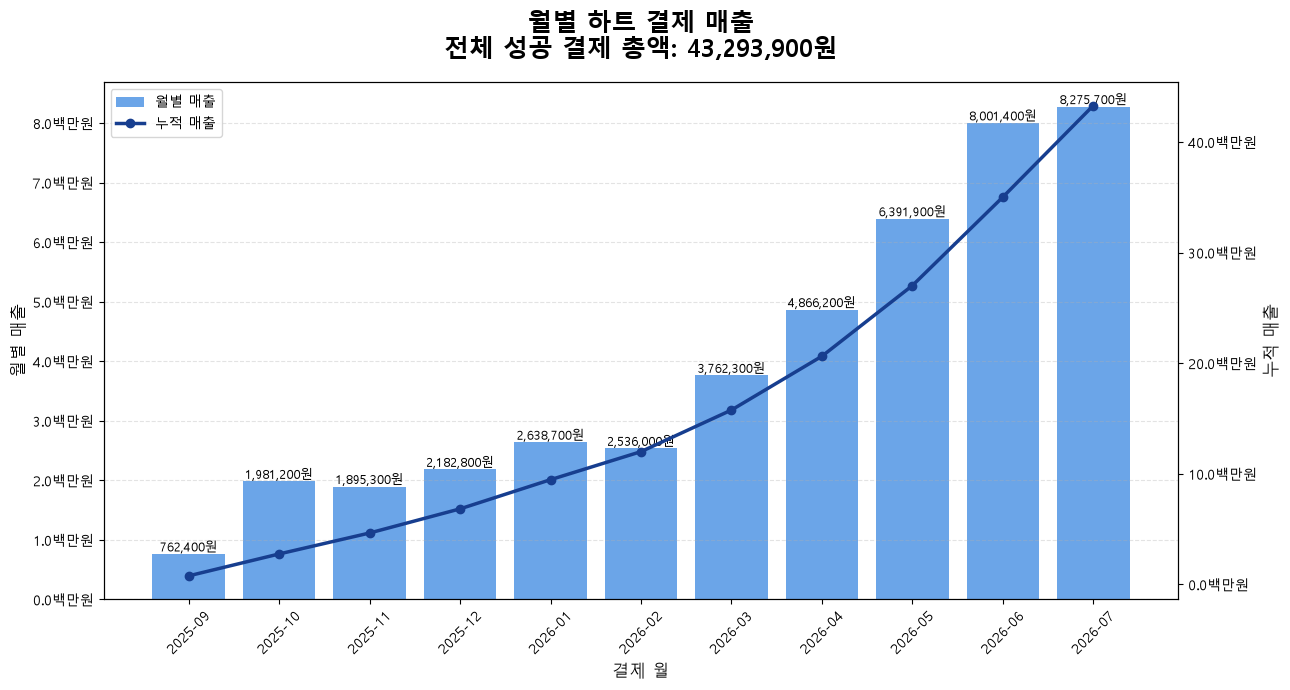

In [6]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Windows와 macOS 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

# 시각화용 데이터 정리
plot_df = revenue_df[
    ["payment_month", "monthly_revenue_krw"]
].copy()

plot_df["payment_month"] = pd.to_datetime(
    plot_df["payment_month"]
)

plot_df = plot_df.sort_values("payment_month")
plot_df["cumulative_revenue_krw"] = (
    plot_df["monthly_revenue_krw"].cumsum()
)

total_revenue = int(
    revenue_df["total_revenue_krw"].iloc[0]
)

# 그래프 생성
fig, ax1 = plt.subplots(figsize=(13, 7))

month_labels = plot_df["payment_month"].dt.strftime("%Y-%m")

bars = ax1.bar(
    month_labels,
    plot_df["monthly_revenue_krw"],
    color="#5B9BE6",
    alpha=0.9,
    label="월별 매출"
)

ax1.set_title(
    f"월별 하트 결제 매출\n전체 성공 결제 총액: {total_revenue:,}원",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax1.set_xlabel("결제 월", fontsize=12)
ax1.set_ylabel("월별 매출", fontsize=12)
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}백만원")
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax1.tick_params(
    axis="x",
    rotation=45
)

# 월별 매출 금액 표시
for bar, value in zip(
    bars,
    plot_df["monthly_revenue_krw"]
):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}원",
        ha="center",
        va="bottom",
        fontsize=9
    )

# 누적 매출 선 그래프
ax2 = ax1.twinx()

ax2.plot(
    month_labels,
    plot_df["cumulative_revenue_krw"],
    color="#173E8F",
    marker="o",
    linewidth=2.5,
    label="누적 매출"
)

ax2.set_ylabel("누적 매출", fontsize=12)
ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}백만원")
)

# 범례 합치기
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

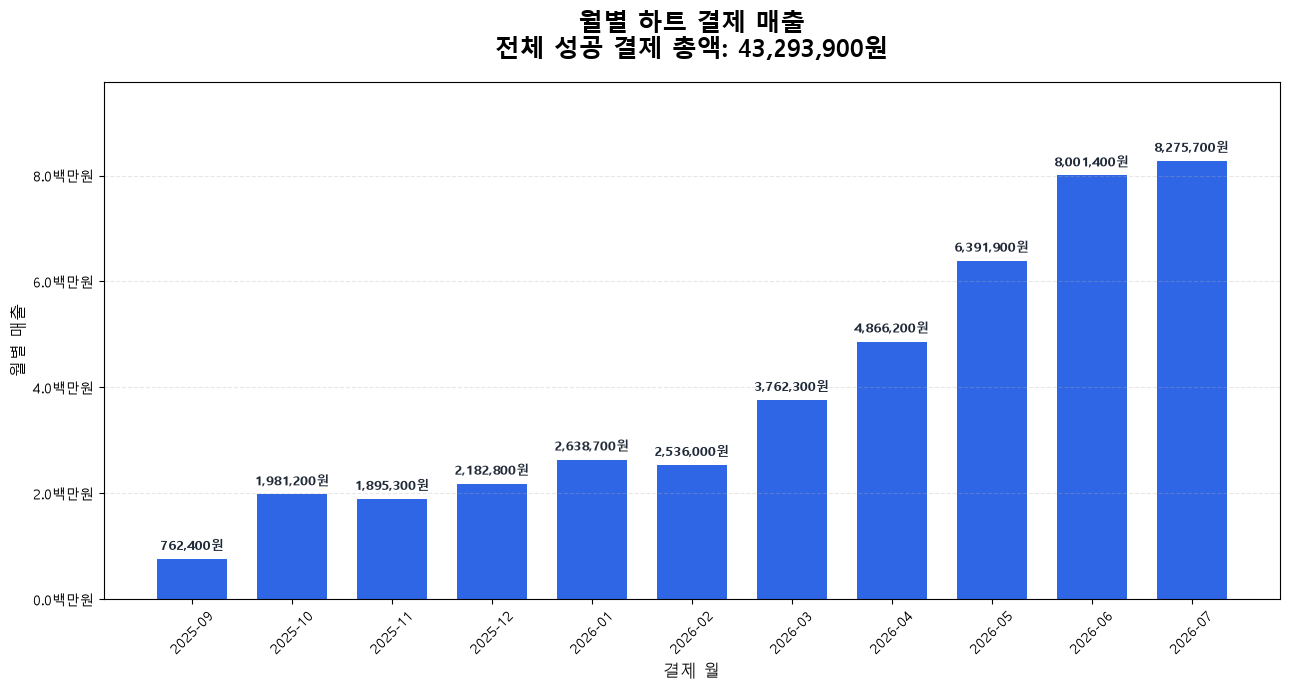

In [7]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Windows·macOS 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

# 시각화용 데이터
plot_df = revenue_df[
    ["payment_month", "monthly_revenue_krw"]
].copy()

plot_df["payment_month"] = pd.to_datetime(
    plot_df["payment_month"]
)

plot_df = plot_df.sort_values("payment_month")

total_revenue = int(
    revenue_df["total_revenue_krw"].iloc[0]
)

# 월별 매출 막대그래프
fig, ax = plt.subplots(figsize=(13, 7))

month_labels = plot_df["payment_month"].dt.strftime("%Y-%m")

bars = ax.bar(
    month_labels,
    plot_df["monthly_revenue_krw"],
    color="#2F66E5",
    width=0.7
)

ax.set_title(
    f"월별 하트 결제 매출\n전체 성공 결제 총액: {total_revenue:,}원",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("결제 월", fontsize=12)
ax.set_ylabel("월별 매출", fontsize=12)

# Y축을 백만원 단위로 표시
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}백만원"
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.tick_params(
    axis="x",
    rotation=45
)

# 막대 위 매출액 표시
y_offset = plot_df["monthly_revenue_krw"].max() * 0.015

for bar, value in zip(
    bars,
    plot_df["monthly_revenue_krw"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_offset,
        f"{int(value):,}원",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#1F2937"
    )

# 금액 표시 공간 확보
ax.set_ylim(
    0,
    plot_df["monthly_revenue_krw"].max() * 1.18
)

plt.tight_layout()
plt.show()

In [8]:
# 힌트 전환율
hint_funnel_sql = """
-- 받은 투표 열람 → 힌트 1·2·3개 → 이름 공개 전환 퍼널
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_received AS (
  SELECT
    id AS vote_received_id,
    receiver_id AS user_id,
    is_read,
    read_at,
    created_at
  FROM `ping-v2-503916.raw.vote_received`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

data_end AS (
  SELECT
    MAX(COALESCE(read_at, created_at)) AS data_end_at
  FROM current_received
),

eligible_received AS (
  SELECT
    r.vote_received_id,
    r.user_id,
    r.read_at
  FROM current_received AS r
  INNER JOIN valid_users AS u
    ON r.user_id = u.user_id
  CROSS JOIN data_end AS d
  WHERE r.is_read = TRUE
    AND r.read_at IS NOT NULL

    -- 열람 후 24시간을 전부 관찰할 수 있는 투표만 포함
    AND r.read_at <= TIMESTAMP_SUB(
      d.data_end_at,
      INTERVAL 24 HOUR
    )
),

current_hint_purchase AS (
  SELECT
    id,
    vote_received_id,
    user_id,
    CAST(hint_type AS STRING) AS hint_type,
    heart_cost,
    created_at
  FROM `ping-v2-503916.raw.hint_purchase`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

hint_status AS (
  SELECT
    r.vote_received_id,
    r.user_id,

    -- 이름 공개를 제외한 기본 힌트 구매 종류 수
    COUNT(
      DISTINCT IF(
        h.hint_type != 'FULL_NAME',
        h.hint_type,
        NULL
      )
    ) AS basic_hint_count,

    COUNTIF(
      h.hint_type = 'FULL_NAME'
    ) > 0 AS purchased_full_name

  FROM eligible_received AS r
  LEFT JOIN current_hint_purchase AS h
    ON r.vote_received_id = h.vote_received_id
    AND r.user_id = h.user_id

    -- 받은 투표를 열람한 후 24시간 이내 구매
    AND h.created_at >= r.read_at
    AND h.created_at < TIMESTAMP_ADD(
      r.read_at,
      INTERVAL 24 HOUR
    )

  GROUP BY
    r.vote_received_id,
    r.user_id
),

stage_counts AS (
  SELECT
    0 AS stage_order,
    '받은 투표 열람' AS stage_name,
    COUNT(*) AS received_vote_count,
    COUNT(DISTINCT user_id) AS user_count
  FROM hint_status

  UNION ALL

  SELECT
    1,
    '힌트 1개 구매',
    COUNTIF(basic_hint_count >= 1),
    COUNT(DISTINCT IF(basic_hint_count >= 1, user_id, NULL))
  FROM hint_status

  UNION ALL

  SELECT
    2,
    '힌트 2개 구매',
    COUNTIF(basic_hint_count >= 2),
    COUNT(DISTINCT IF(basic_hint_count >= 2, user_id, NULL))
  FROM hint_status

  UNION ALL

  SELECT
    3,
    '힌트 3개 구매',
    COUNTIF(basic_hint_count >= 3),
    COUNT(DISTINCT IF(basic_hint_count >= 3, user_id, NULL))
  FROM hint_status

  UNION ALL

  SELECT
    4,
    '이름 공개',
    COUNTIF(
      basic_hint_count >= 3
      AND purchased_full_name
    ),
    COUNT(
      DISTINCT IF(
        basic_hint_count >= 3
        AND purchased_full_name,
        user_id,
        NULL
      )
    )
  FROM hint_status
),

stage_with_previous AS (
  SELECT
    *,
    FIRST_VALUE(received_vote_count) OVER (
      ORDER BY stage_order
    ) AS entry_count,

    LAG(received_vote_count) OVER (
      ORDER BY stage_order
    ) AS previous_count
  FROM stage_counts
)

SELECT
  stage_order,
  stage_name,
  received_vote_count,
  user_count,

  ROUND(
    SAFE_DIVIDE(
      received_vote_count,
      entry_count
    ) * 100,
    2
  ) AS entry_conversion_percent,

  ROUND(
    CASE
      WHEN stage_order = 0 THEN 100
      ELSE SAFE_DIVIDE(
        received_vote_count,
        previous_count
      ) * 100
    END,
    2
  ) AS previous_stage_conversion_percent,

  CASE
    WHEN stage_order = 0 THEN 0
    ELSE previous_count - received_vote_count
  END AS dropoff_count,

  ROUND(
    CASE
      WHEN stage_order = 0 THEN 0
      ELSE (
        1 - SAFE_DIVIDE(
          received_vote_count,
          previous_count
        )
      ) * 100
    END,
    2
  ) AS dropoff_percent

FROM stage_with_previous
ORDER BY stage_order
"""

In [9]:
cost(hint_funnel_sql)

예상 스캔량: 633.396 MiB
예상 스캔량: 0.618551 GiB
월 1 TiB 무료 용량의 약 0.06040538%


0.618551092222333

In [10]:
hint_funnel_df = bq.query(
    hint_funnel_sql
).to_dataframe()

display(hint_funnel_df)

,stage_order,stage_name,received_vote_count,user_count,entry_conversion_percent,previous_stage_conversion_percent,dropoff_count,dropoff_percent
0,0,받은 투표 열람,6400235,16695,100.00,100.00,0,0.00
1,1,힌트 1개 구매,1015850,13711,15.87,15.87,5384385,84.13
2,2,힌트 2개 구매,286369,13029,4.47,28.19,729481,71.81
3,3,힌트 3개 구매,98300,11858,1.54,34.33,188069,65.67
4,4,이름 공개,7590,4418,0.12,7.72,90710,92.28


In [11]:
print("[힌트 구매 단계별 전환율]")

for _, row in hint_funnel_df.iterrows():
    stage = row["stage_name"]
    vote_count = int(row["received_vote_count"])
    user_count = int(row["user_count"])
    entry_rate = float(row["entry_conversion_percent"])
    step_rate = float(row["previous_stage_conversion_percent"])
    dropoff_count = int(row["dropoff_count"])
    dropoff_rate = float(row["dropoff_percent"])

    if int(row["stage_order"]) == 0:
        print(
            f"{stage}: {vote_count:,}건 / "
            f"{user_count:,}명 (기준 100%)"
        )
    else:
        print(
            f"{stage}: {vote_count:,}건 / "
            f"{user_count:,}명 | "
            f"열람 대비 {entry_rate:.2f}% | "
            f"직전 단계 전환율 {step_rate:.2f}% | "
            f"이탈 {dropoff_count:,}건 ({dropoff_rate:.2f}%)"
        )

# 이탈률이 가장 높은 구간
dropoff_rows = hint_funnel_df[
    hint_funnel_df["stage_order"] > 0
]

largest_dropoff = dropoff_rows.loc[
    dropoff_rows["dropoff_percent"].idxmax()
]

print()
print(
    "가장 큰 이탈 구간: "
    f"{largest_dropoff['stage_name']} 진입 전"
)

print(
    f"직전 단계 대비 이탈률: "
    f"{largest_dropoff['dropoff_percent']:.2f}%"
)

[힌트 구매 단계별 전환율]
받은 투표 열람: 6,400,235건 / 16,695명 (기준 100%)
힌트 1개 구매: 1,015,850건 / 13,711명 | 열람 대비 15.87% | 직전 단계 전환율 15.87% | 이탈 5,384,385건 (84.13%)
힌트 2개 구매: 286,369건 / 13,029명 | 열람 대비 4.47% | 직전 단계 전환율 28.19% | 이탈 729,481건 (71.81%)
힌트 3개 구매: 98,300건 / 11,858명 | 열람 대비 1.54% | 직전 단계 전환율 34.33% | 이탈 188,069건 (65.67%)
이름 공개: 7,590건 / 4,418명 | 열람 대비 0.12% | 직전 단계 전환율 7.72% | 이탈 90,710건 (92.28%)

가장 큰 이탈 구간: 이름 공개 진입 전
직전 단계 대비 이탈률: 92.28%


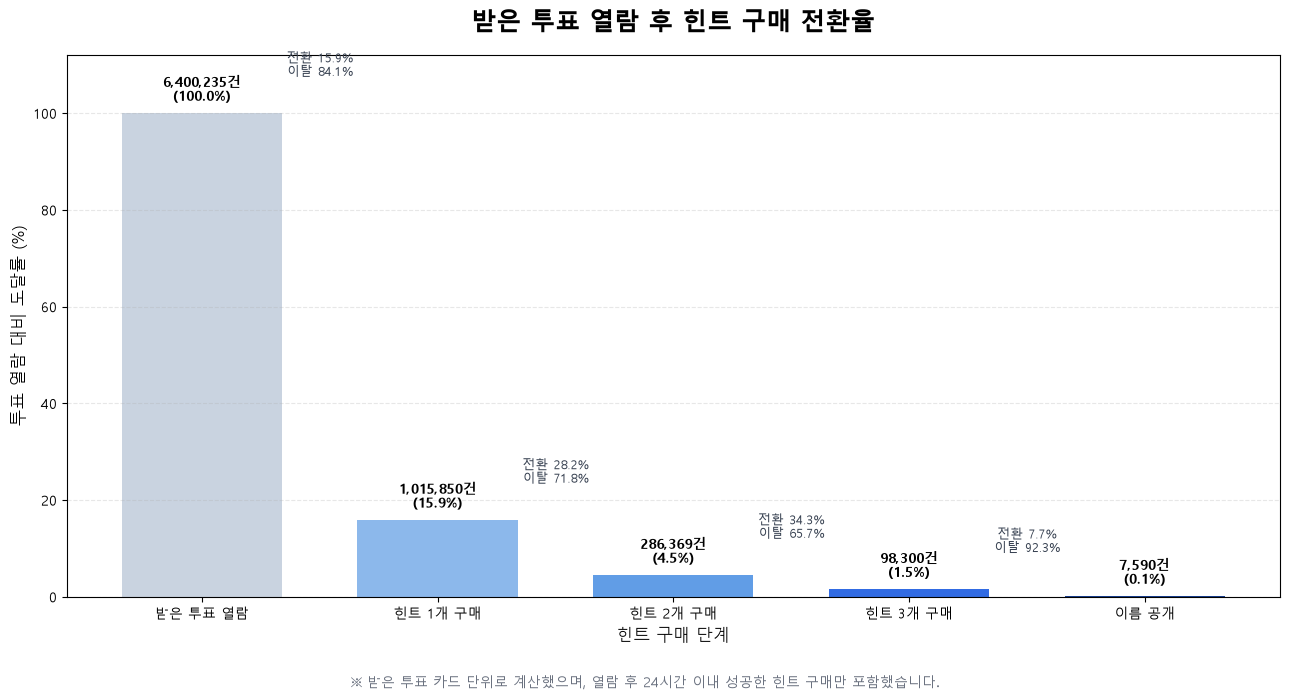

In [12]:
import platform
import matplotlib.pyplot as plt

# Windows·macOS 한글 폰트
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = hint_funnel_df.sort_values(
    "stage_order"
).copy()

stage_names = plot_df["stage_name"]
conversion_rates = plot_df["entry_conversion_percent"]
counts = plot_df["received_vote_count"]

colors = [
    "#C9D3E0",
    "#8CB8EB",
    "#619DE6",
    "#316BE3",
    "#173E8F"
]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    stage_names,
    conversion_rates,
    color=colors,
    width=0.68
)

ax.set_title(
    "받은 투표 열람 후 힌트 구매 전환율",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("힌트 구매 단계", fontsize=12)
ax.set_ylabel("투표 열람 대비 도달률 (%)", fontsize=12)
ax.set_ylim(0, 112)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# 각 막대의 건수와 누적 전환율
for bar, count, rate in zip(
    bars,
    counts,
    conversion_rates
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{int(count):,}건\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# 직전 단계 전환율과 이탈률 표시
for index in range(1, len(plot_df)):
    previous_bar = bars[index - 1]
    current_bar = bars[index]

    x_position = (
        previous_bar.get_x()
        + previous_bar.get_width()
        + current_bar.get_x()
    ) / 2

    y_position = max(
        conversion_rates.iloc[index - 1],
        conversion_rates.iloc[index]
    ) + 10

    step_rate = plot_df.iloc[index][
        "previous_stage_conversion_percent"
    ]

    dropoff_rate = plot_df.iloc[index][
        "dropoff_percent"
    ]

    ax.text(
        x_position,
        y_position,
        f"전환 {step_rate:.1f}%\n이탈 {dropoff_rate:.1f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="#374151"
    )

plt.figtext(
    0.5,
    0.01,
    "※ 받은 투표 카드 단위로 계산했으며, 열람 후 24시간 이내 성공한 힌트 구매만 포함했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [13]:
# 투표 수신 미경험률
vote_receive_experience_sql = """
-- 전체 유효 사용자 중 투표 수신 경험·미경험 비율
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_vote_received AS (
  SELECT
    id AS vote_received_id,
    receiver_id
  FROM `ping-v2-503916.raw.vote_received`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

received_users AS (
  SELECT DISTINCT
    receiver_id AS user_id
  FROM current_vote_received
  WHERE receiver_id IS NOT NULL
),

user_status AS (
  SELECT
    u.user_id,
    IF(
      r.user_id IS NOT NULL,
      '투표 수신 경험',
      '투표 수신 미경험'
    ) AS receive_status
  FROM valid_users AS u
  LEFT JOIN received_users AS r
    ON u.user_id = r.user_id
),

status_count AS (
  SELECT
    receive_status,
    COUNT(*) AS user_count
  FROM user_status
  GROUP BY receive_status
),

total AS (
  SELECT
    COUNT(*) AS total_user_count
  FROM user_status
)

SELECT
  s.receive_status,
  s.user_count,
  t.total_user_count,

  ROUND(
    SAFE_DIVIDE(
      s.user_count,
      t.total_user_count
    ) * 100,
    2
  ) AS user_percent

FROM status_count AS s
CROSS JOIN total AS t

ORDER BY
  CASE
    WHEN s.receive_status = '투표 수신 경험' THEN 1
    ELSE 2
  END
"""

In [14]:
cost(vote_receive_experience_sql)

예상 스캔량: 383.271 MiB
예상 스캔량: 0.374288 GiB
월 1 TiB 무료 용량의 약 0.03655160%


0.3742883475497365

In [15]:
vote_receive_df = bq.query(
    vote_receive_experience_sql
).to_dataframe()

display(vote_receive_df)

,receive_status,user_count,total_user_count,user_percent
0,투표 수신 경험,16822,18001,93.45
1,투표 수신 미경험,1179,18001,6.55


In [16]:
total_user_count = int(
    vote_receive_df["total_user_count"].iloc[0]
)

experienced_row = vote_receive_df[
    vote_receive_df["receive_status"] == "투표 수신 경험"
].iloc[0]

unexperienced_row = vote_receive_df[
    vote_receive_df["receive_status"] == "투표 수신 미경험"
].iloc[0]

experienced_count = int(
    experienced_row["user_count"]
)
experienced_rate = float(
    experienced_row["user_percent"]
)

unexperienced_count = int(
    unexperienced_row["user_count"]
)
unexperienced_rate = float(
    unexperienced_row["user_percent"]
)

print("[투표 수신 경험 분석]")
print(f"전체 유효 사용자: {total_user_count:,}명")

print(
    f"투표 수신 경험 사용자: "
    f"{experienced_count:,}명 ({experienced_rate:.2f}%)"
)

print(
    f"투표 수신 미경험 사용자: "
    f"{unexperienced_count:,}명 ({unexperienced_rate:.2f}%)"
)

print()
print(
    f"전체 유효 사용자 약 100명 중 "
    f"{unexperienced_rate:.1f}명은 "
    f"다른 사용자에게 투표를 한 번도 받지 못했습니다."
)

[투표 수신 경험 분석]
전체 유효 사용자: 18,001명
투표 수신 경험 사용자: 16,822명 (93.45%)
투표 수신 미경험 사용자: 1,179명 (6.55%)

전체 유효 사용자 약 100명 중 6.5명은 다른 사용자에게 투표를 한 번도 받지 못했습니다.


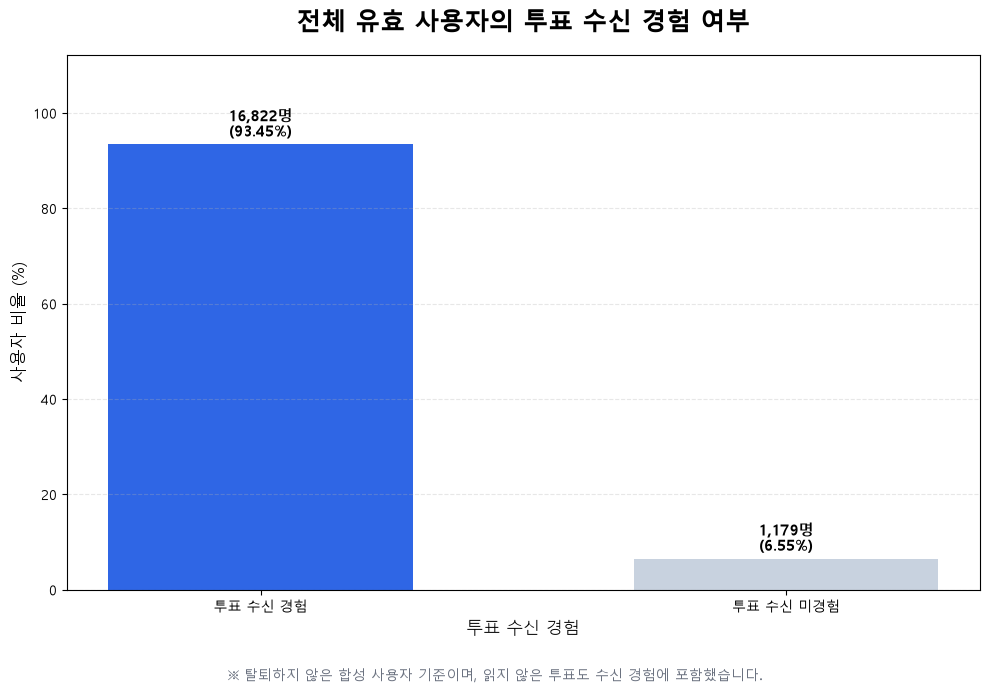

In [17]:
import platform
import matplotlib.pyplot as plt

# Windows·macOS 한글 폰트
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = vote_receive_df.copy()

colors = {
    "투표 수신 경험": "#2F66E5",
    "투표 수신 미경험": "#C8D2DF"
}

bar_colors = [
    colors[status]
    for status in plot_df["receive_status"]
]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(
    plot_df["receive_status"],
    plot_df["user_percent"],
    color=bar_colors,
    width=0.58
)

ax.set_title(
    "전체 유효 사용자의 투표 수신 경험 여부",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("투표 수신 경험", fontsize=12)
ax.set_ylabel("사용자 비율 (%)", fontsize=12)

ax.set_ylim(
    0,
    max(plot_df["user_percent"].max() * 1.2, 20)
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar, (_, row) in zip(
    bars,
    plot_df.iterrows()
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        (
            f"{int(row['user_count']):,}명\n"
            f"({row['user_percent']:.2f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.figtext(
    0.5,
    0.02,
    "※ 탈퇴하지 않은 합성 사용자 기준이며, 읽지 않은 투표도 수신 경험에 포함했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [18]:
# 친구 5명 해금 여부
unreceived_unlock_sql = """
-- 투표 수신 미경험 사용자 중 친구 5명 해금 여부
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic,
    friend_count,
    service_unlocked_at
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id,
    u.friend_count,
    u.service_unlocked_at
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_vote_received AS (
  SELECT
    id AS vote_received_id,
    receiver_id
  FROM `ping-v2-503916.raw.vote_received`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

received_users AS (
  SELECT DISTINCT
    receiver_id AS user_id
  FROM current_vote_received
  WHERE receiver_id IS NOT NULL
),

unreceived_users AS (
  SELECT
    u.user_id,
    u.friend_count,
    u.service_unlocked_at,

    CASE
      WHEN u.service_unlocked_at IS NULL
        THEN '친구 5명 미해금'
      ELSE '친구 5명 해금'
    END AS unlock_status

  FROM valid_users AS u
  LEFT JOIN received_users AS r
    ON u.user_id = r.user_id
  WHERE r.user_id IS NULL
),

status_count AS (
  SELECT
    unlock_status,
    COUNT(*) AS user_count
  FROM unreceived_users
  GROUP BY unlock_status
),

summary AS (
  SELECT
    COUNT(*) AS unreceived_user_count
  FROM unreceived_users
),

valid_user_summary AS (
  SELECT
    COUNT(*) AS total_valid_user_count
  FROM valid_users
)

SELECT
  s.unlock_status,
  s.user_count,
  a.unreceived_user_count,
  v.total_valid_user_count,

  ROUND(
    SAFE_DIVIDE(
      s.user_count,
      a.unreceived_user_count
    ) * 100,
    2
  ) AS share_among_unreceived_percent,

  ROUND(
    SAFE_DIVIDE(
      s.user_count,
      v.total_valid_user_count
    ) * 100,
    2
  ) AS share_among_total_percent

FROM status_count AS s
CROSS JOIN summary AS a
CROSS JOIN valid_user_summary AS v

ORDER BY
  CASE
    WHEN s.unlock_status = '친구 5명 미해금' THEN 1
    ELSE 2
  END
"""

In [19]:
cost(unreceived_unlock_sql)

예상 스캔량: 383.413 MiB
예상 스캔량: 0.374427 GiB
월 1 TiB 무료 용량의 약 0.03656510%


0.374426600523293

In [21]:
unreceived_unlock_df = bq.query(
    unreceived_unlock_sql
).to_dataframe()

display(unreceived_unlock_df)

,unlock_status,user_count,unreceived_user_count,total_valid_user_count,share_among_unreceived_percent,share_among_total_percent
0,친구 5명 미해금,528,1179,18001,44.78,2.93
1,친구 5명 해금,651,1179,18001,55.22,3.62


In [22]:
unreceived_total = int(
    unreceived_unlock_df["unreceived_user_count"].iloc[0]
)

valid_total = int(
    unreceived_unlock_df["total_valid_user_count"].iloc[0]
)

print("[투표 수신 미경험 사용자의 친구 5명 해금 여부]")
print(f"전체 유효 사용자: {valid_total:,}명")
print(f"투표 수신 미경험 사용자: {unreceived_total:,}명")
print()

for _, row in unreceived_unlock_df.iterrows():
    print(
        f"{row['unlock_status']}: "
        f"{int(row['user_count']):,}명 | "
        f"수신 미경험자 중 {row['share_among_unreceived_percent']:.2f}% | "
        f"전체 사용자 중 {row['share_among_total_percent']:.2f}%"
    )

[투표 수신 미경험 사용자의 친구 5명 해금 여부]
전체 유효 사용자: 18,001명
투표 수신 미경험 사용자: 1,179명

친구 5명 미해금: 528명 | 수신 미경험자 중 44.78% | 전체 사용자 중 2.93%
친구 5명 해금: 651명 | 수신 미경험자 중 55.22% | 전체 사용자 중 3.62%


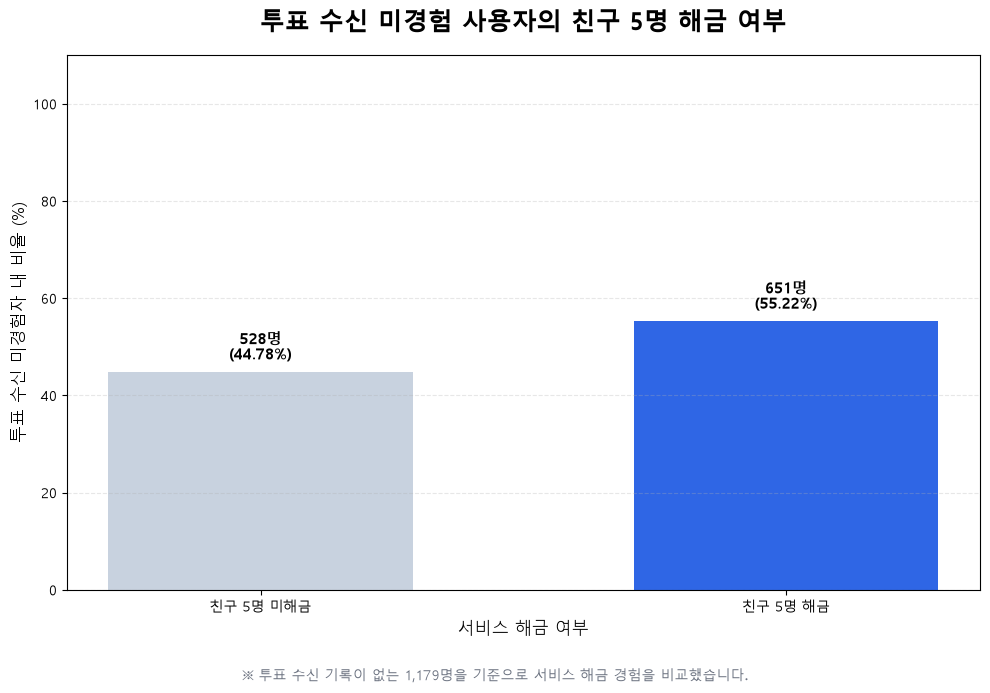

In [23]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = unreceived_unlock_df.copy()

colors = {
    "친구 5명 미해금": "#C8D2DF",
    "친구 5명 해금": "#2F66E5"
}

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(
    plot_df["unlock_status"],
    plot_df["share_among_unreceived_percent"],
    color=[
        colors[status]
        for status in plot_df["unlock_status"]
    ],
    width=0.58
)

ax.set_title(
    "투표 수신 미경험 사용자의 친구 5명 해금 여부",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("서비스 해금 여부", fontsize=12)
ax.set_ylabel("투표 수신 미경험자 내 비율 (%)", fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis="y", linestyle="--", alpha=0.3)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        (
            f"{int(row['user_count']):,}명\n"
            f"({row['share_among_unreceived_percent']:.2f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.figtext(
    0.5,
    0.02,
    "※ 투표 수신 기록이 없는 1,179명을 기준으로 서비스 해금 경험을 비교했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [24]:
# 투표 세트 완료율
vote_set_completion_sql = """
-- 10문항 투표 세트 단계별 완료율
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_sessions AS (
  SELECT
    id AS session_id,
    user_id,
    status,
    item_count,
    started_at,
    completed_at
  FROM `ping-v2-503916.raw.vote_session`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

current_items AS (
  SELECT
    id AS vote_item_id,
    session_id,
    voted_at
  FROM `ping-v2-503916.raw.vote_item`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

session_progress AS (
  SELECT
    s.session_id,
    s.user_id,
    s.status,
    s.item_count,

    COUNT(i.vote_item_id) AS actual_item_count,

    COUNTIF(
      i.voted_at IS NOT NULL
    ) AS voted_item_count

  FROM current_sessions AS s
  INNER JOIN valid_users AS u
    ON s.user_id = u.user_id
  LEFT JOIN current_items AS i
    ON s.session_id = i.session_id

  GROUP BY
    s.session_id,
    s.user_id,
    s.status,
    s.item_count
),

-- 실제로 10문항이 제공된 세션만 사용자 완주율 분석에 사용
eligible_sessions AS (
  SELECT *
  FROM session_progress
  WHERE item_count = 10
    AND actual_item_count = 10
),

stage_counts AS (
  SELECT
    stage AS stage_order,

    CASE
      WHEN stage = 0 THEN '세트 시작'
      WHEN stage = 10 THEN '10문항 완료'
      ELSE CONCAT(CAST(stage AS STRING), '문항 완료')
    END AS stage_name,

    COUNTIF(
      e.voted_item_count >= stage
    ) AS reached_session_count,

    COUNT(
      DISTINCT IF(
        e.voted_item_count >= stage,
        e.user_id,
        NULL
      )
    ) AS reached_user_count

  FROM UNNEST(GENERATE_ARRAY(0, 10)) AS stage
  CROSS JOIN eligible_sessions AS e

  GROUP BY stage
),

session_summary AS (
  SELECT
    COUNT(*) AS total_started_session_count,

    COUNTIF(
      item_count = 10
      AND actual_item_count = 10
    ) AS eligible_session_count,

    COUNTIF(
      status = 'COMPLETED'
    ) AS status_completed_count,

    COUNTIF(
      item_count = 10
      AND actual_item_count = 10
      AND voted_item_count = 10
    ) AS strict_completed_count,

    -- status는 완료지만 실제 10문항을 끝내지 않은 세션
    COUNTIF(
      status = 'COMPLETED'
      AND NOT (
        item_count = 10
        AND actual_item_count = 10
        AND voted_item_count = 10
      )
    ) AS false_completed_count

  FROM session_progress
),

stage_with_previous AS (
  SELECT
    s.*,

    FIRST_VALUE(reached_session_count) OVER (
      ORDER BY stage_order
    ) AS starting_session_count,

    LAG(reached_session_count) OVER (
      ORDER BY stage_order
    ) AS previous_stage_count

  FROM stage_counts AS s
)

SELECT
  p.stage_order,
  p.stage_name,
  p.reached_session_count,
  p.reached_user_count,

  ROUND(
    SAFE_DIVIDE(
      p.reached_session_count,
      p.starting_session_count
    ) * 100,
    2
  ) AS cumulative_completion_percent,

  ROUND(
    CASE
      WHEN p.stage_order = 0 THEN 100
      ELSE SAFE_DIVIDE(
        p.reached_session_count,
        p.previous_stage_count
      ) * 100
    END,
    2
  ) AS previous_stage_conversion_percent,

  CASE
    WHEN p.stage_order = 0 THEN 0
    ELSE p.previous_stage_count - p.reached_session_count
  END AS stage_dropoff_count,

  ROUND(
    CASE
      WHEN p.stage_order = 0 THEN 0
      ELSE (
        1 - SAFE_DIVIDE(
          p.reached_session_count,
          p.previous_stage_count
        )
      ) * 100
    END,
    2
  ) AS stage_dropoff_percent,

  sm.total_started_session_count,
  sm.eligible_session_count,
  sm.status_completed_count,
  sm.strict_completed_count,
  sm.false_completed_count,

  ROUND(
    SAFE_DIVIDE(
      sm.eligible_session_count,
      sm.total_started_session_count
    ) * 100,
    2
  ) AS ten_item_served_percent

FROM stage_with_previous AS p
CROSS JOIN session_summary AS sm
ORDER BY p.stage_order
"""

In [25]:
cost(vote_set_completion_sql)

예상 스캔량: 567.221 MiB
예상 스캔량: 0.553927 GiB
월 1 TiB 무료 용량의 약 0.05409439%


0.5539265088737011

In [26]:
vote_set_funnel_df = bq.query(
    vote_set_completion_sql
).to_dataframe()

display(vote_set_funnel_df)

,stage_order,stage_name,reached_session_count,reached_user_count,cumulative_completion_percent,previous_stage_conversion_percent,stage_dropoff_count,stage_dropoff_percent,total_started_session_count,eligible_session_count,status_completed_count,strict_completed_count,false_completed_count,ten_item_served_percent
0,0,세트 시작,1157690,12506,100.00,100.00,0,0.00,1366593,1157690,1151831,794045,357786,84.71
1,1,1문항 완료,1157690,12506,100.00,100.00,0,0.00,1366593,1157690,1151831,794045,357786,84.71
2,2,2문항 완료,1157690,12506,100.00,100.00,0,0.00,1366593,1157690,1151831,794045,357786,84.71
3,3,3문항 완료,1157690,12506,100.00,100.00,0,0.00,1366593,1157690,1151831,794045,357786,84.71
4,4,4문항 완료,1157690,12506,100.00,100.00,0,0.00,1366593,1157690,1151831,794045,357786,84.71
5,5,5문항 완료,1157689,12506,100.00,100.00,1,0.00,1366593,1157690,1151831,794045,357786,84.71
6,6,6문항 완료,1157664,12506,100.00,100.00,25,0.00,1366593,1157690,1151831,794045,357786,84.71
7,7,7문항 완료,1157291,12500,99.97,99.97,373,0.03,1366593,1157690,1151831,794045,357786,84.71
8,8,8문항 완료,1151830,12482,99.49,99.53,5461,0.47,1366593,1157690,1151831,794045,357786,84.71
9,9,9문항 완료,1099032,12273,94.93,95.42,52798,4.58,1366593,1157690,1151831,794045,357786,84.71


In [27]:
if vote_set_funnel_df.empty:
    print("조회된 투표 세션이 없습니다.")

else:
    start_row = vote_set_funnel_df[
        vote_set_funnel_df["stage_order"] == 0
    ].iloc[0]

    complete_row = vote_set_funnel_df[
        vote_set_funnel_df["stage_order"] == 10
    ].iloc[0]

    total_sessions = int(
        start_row["total_started_session_count"]
    )

    eligible_sessions = int(
        start_row["eligible_session_count"]
    )

    completed_sessions = int(
        complete_row["reached_session_count"]
    )

    completion_rate = float(
        complete_row["cumulative_completion_percent"]
    )

    ten_item_served_rate = float(
        start_row["ten_item_served_percent"]
    )

    status_completed = int(
        start_row["status_completed_count"]
    )

    false_completed = int(
        start_row["false_completed_count"]
    )

    print("[10문항 투표 세트 완료 분석]")
    print(f"전체 시작 세션: {total_sessions:,}건")

    print(
        f"10문항 정상 구성 세션: "
        f"{eligible_sessions:,}건 "
        f"({ten_item_served_rate:.2f}%)"
    )

    print(
        f"10문항 실제 완료 세션: "
        f"{completed_sessions:,}건 "
        f"({completion_rate:.2f}%)"
    )

    print(
        f"상태값상 완료 세션: "
        f"{status_completed:,}건"
    )

    print(
        f"상태는 완료지만 실제 10문항 미완료: "
        f"{false_completed:,}건"
    )

    # 가장 이탈률이 높은 투표 구간
    dropoff_df = vote_set_funnel_df[
        vote_set_funnel_df["stage_order"] > 0
    ]

    largest_dropoff = dropoff_df.loc[
        dropoff_df["stage_dropoff_percent"].idxmax()
    ]

    print()
    print(
        f"가장 큰 이탈 구간: "
        f"{int(largest_dropoff['stage_order']) - 1}문항 완료"
        f" → {int(largest_dropoff['stage_order'])}문항 완료"
    )

    print(
        f"해당 구간 이탈: "
        f"{int(largest_dropoff['stage_dropoff_count']):,}건 "
        f"({float(largest_dropoff['stage_dropoff_percent']):.2f}%)"
    )

[10문항 투표 세트 완료 분석]
전체 시작 세션: 1,366,593건
10문항 정상 구성 세션: 1,157,690건 (84.71%)
10문항 실제 완료 세션: 794,045건 (68.59%)
상태값상 완료 세션: 1,151,831건
상태는 완료지만 실제 10문항 미완료: 357,786건

가장 큰 이탈 구간: 9문항 완료 → 10문항 완료
해당 구간 이탈: 304,987건 (27.75%)


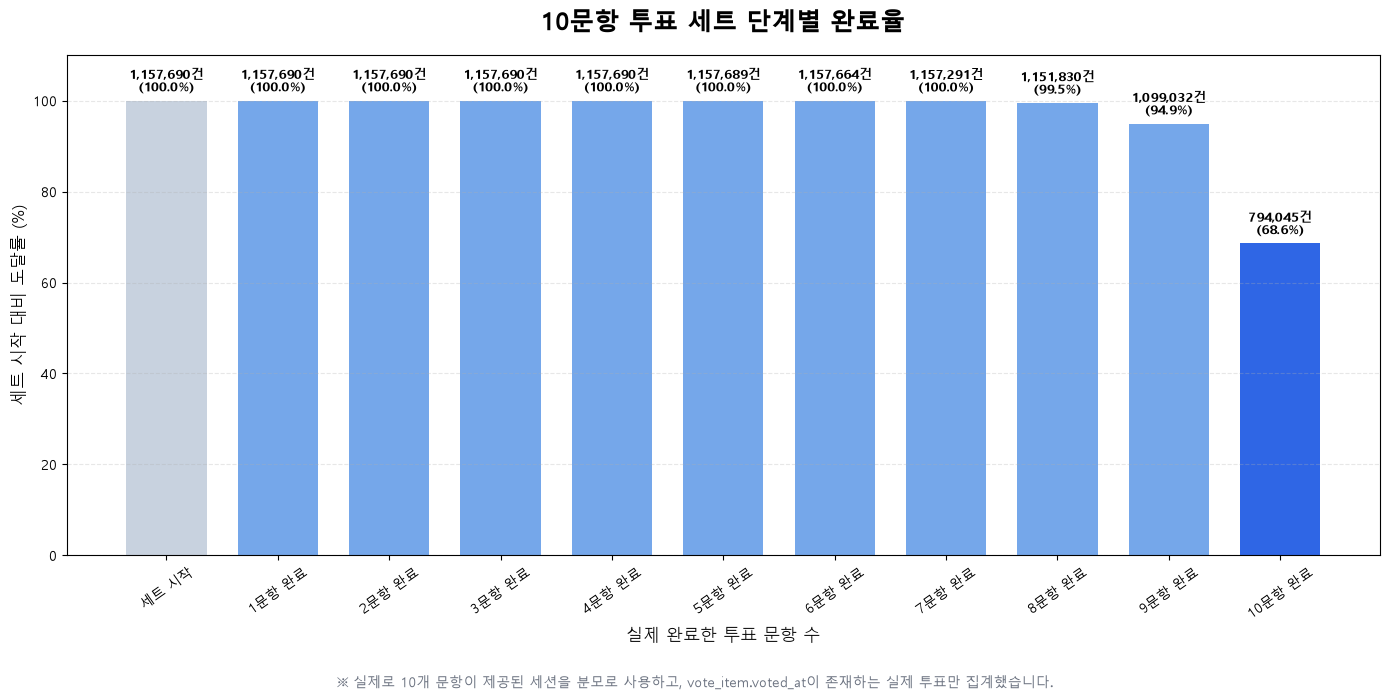

In [28]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = vote_set_funnel_df.sort_values(
    "stage_order"
).copy()

fig, ax = plt.subplots(figsize=(14, 7))

colors = [
    "#C8D2DF" if stage == 0
    else "#2F66E5" if stage == 10
    else "#75A7EA"
    for stage in plot_df["stage_order"]
]

bars = ax.bar(
    plot_df["stage_name"],
    plot_df["cumulative_completion_percent"],
    color=colors,
    width=0.72
)

ax.set_title(
    "10문항 투표 세트 단계별 완료율",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("실제 완료한 투표 문항 수", fontsize=12)
ax.set_ylabel("세트 시작 대비 도달률 (%)", fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis="y", linestyle="--", alpha=0.3)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        (
            f"{int(row['reached_session_count']):,}건\n"
            f"({row['cumulative_completion_percent']:.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.tick_params(axis="x", rotation=35)

plt.figtext(
    0.5,
    0.01,
    "※ 실제로 10개 문항이 제공된 세션을 분모로 사용하고, vote_item.voted_at이 존재하는 실제 투표만 집계했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [29]:
# 유저당 신규 친구 수 쿼리
new_friends_per_user_sql = """
-- 가입 후 7일 내 사용자당 신규 친구 수
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic,
    created_at,
    last_active_at
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

current_friendships AS (
  SELECT
    id AS friendship_id,
    user_low_id,
    user_high_id,
    created_at,
    ended_at
  FROM `ping-v2-503916.raw.friendship`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

data_end AS (
  SELECT
    MAX(
      COALESCE(last_active_at, created_at)
    ) AS data_end_at
  FROM current_users
),

valid_users AS (
  SELECT
    u.user_id,
    u.created_at AS signup_at
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  CROSS JOIN data_end AS d
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL

    -- 가입 후 7일을 모두 관찰할 수 있는 사용자만 포함
    AND u.created_at <= TIMESTAMP_SUB(
      d.data_end_at,
      INTERVAL 7 DAY
    )
),

-- 친구 관계 한 건을 양쪽 사용자 관점으로 변환
friendship_events AS (
  SELECT
    friendship_id,
    user_low_id AS user_id,
    user_high_id AS friend_user_id,
    created_at AS friend_created_at
  FROM current_friendships

  UNION ALL

  SELECT
    friendship_id,
    user_high_id AS user_id,
    user_low_id AS friend_user_id,
    created_at AS friend_created_at
  FROM current_friendships
),

per_user AS (
  SELECT
    u.user_id,

    COUNT(
      DISTINCT f.friendship_id
    ) AS new_friend_count

  FROM valid_users AS u
  LEFT JOIN friendship_events AS f
    ON u.user_id = f.user_id
    AND f.friend_created_at >= u.signup_at
    AND f.friend_created_at < TIMESTAMP_ADD(
      u.signup_at,
      INTERVAL 7 DAY
    )

  GROUP BY u.user_id
),

bucketed AS (
  SELECT
    user_id,
    new_friend_count,

    CASE
      WHEN new_friend_count = 0 THEN '0명'
      WHEN new_friend_count BETWEEN 1 AND 2 THEN '1~2명'
      WHEN new_friend_count BETWEEN 3 AND 4 THEN '3~4명'
      WHEN new_friend_count BETWEEN 5 AND 9 THEN '5~9명'
      ELSE '10명 이상'
    END AS friend_count_group,

    CASE
      WHEN new_friend_count = 0 THEN 1
      WHEN new_friend_count BETWEEN 1 AND 2 THEN 2
      WHEN new_friend_count BETWEEN 3 AND 4 THEN 3
      WHEN new_friend_count BETWEEN 5 AND 9 THEN 4
      ELSE 5
    END AS group_order

  FROM per_user
),

summary AS (
  SELECT
    COUNT(*) AS total_user_count,

    ROUND(
      AVG(new_friend_count),
      2
    ) AS avg_new_friend_count,

    APPROX_QUANTILES(
      new_friend_count,
      100
    )[OFFSET(50)] AS median_new_friend_count,

    APPROX_QUANTILES(
      new_friend_count,
      100
    )[OFFSET(25)] AS p25_new_friend_count,

    APPROX_QUANTILES(
      new_friend_count,
      100
    )[OFFSET(75)] AS p75_new_friend_count,

    COUNTIF(
      new_friend_count = 0
    ) AS zero_friend_user_count,

    COUNTIF(
      new_friend_count >= 5
    ) AS five_friend_user_count

  FROM per_user
),

group_summary AS (
  SELECT
    friend_count_group,
    group_order,
    COUNT(*) AS user_count
  FROM bucketed
  GROUP BY
    friend_count_group,
    group_order
)

SELECT
  g.friend_count_group,
  g.group_order,
  g.user_count,
  s.total_user_count,

  ROUND(
    SAFE_DIVIDE(
      g.user_count,
      s.total_user_count
    ) * 100,
    2
  ) AS user_percent,

  s.avg_new_friend_count,
  s.median_new_friend_count,
  s.p25_new_friend_count,
  s.p75_new_friend_count,
  s.zero_friend_user_count,
  s.five_friend_user_count,

  ROUND(
    SAFE_DIVIDE(
      s.five_friend_user_count,
      s.total_user_count
    ) * 100,
    2
  ) AS five_friend_rate_percent

FROM group_summary AS g
CROSS JOIN summary AS s
ORDER BY g.group_order
"""

In [30]:
cost(new_friends_per_user_sql)

예상 스캔량: 18.625 MiB
예상 스캔량: 0.018188 GiB
월 1 TiB 무료 용량의 약 0.00177619%


0.018188171088695526

In [31]:
new_friends_df = bq.query(
    new_friends_per_user_sql
).to_dataframe()

display(new_friends_df)

,friend_count_group,group_order,user_count,total_user_count,user_percent,avg_new_friend_count,median_new_friend_count,p25_new_friend_count,p75_new_friend_count,zero_friend_user_count,five_friend_user_count,five_friend_rate_percent
0,0명,1,688,17750,3.88,15.01,12,7,18,688,14935,84.14
1,1~2명,2,1131,17750,6.37,15.01,12,7,18,688,14935,84.14
2,3~4명,3,996,17750,5.61,15.01,12,7,18,688,14935,84.14
3,5~9명,4,3418,17750,19.26,15.01,12,7,18,688,14935,84.14
4,10명 이상,5,11517,17750,64.88,15.01,12,7,18,688,14935,84.14


In [32]:
if new_friends_df.empty:
    print("조회된 사용자가 없습니다.")

else:
    first_row = new_friends_df.iloc[0]

    total_users = int(
        first_row["total_user_count"]
    )

    average_count = float(
        first_row["avg_new_friend_count"]
    )

    median_count = int(
        first_row["median_new_friend_count"]
    )

    p25_count = int(
        first_row["p25_new_friend_count"]
    )

    p75_count = int(
        first_row["p75_new_friend_count"]
    )

    zero_count = int(
        first_row["zero_friend_user_count"]
    )

    five_count = int(
        first_row["five_friend_user_count"]
    )

    five_rate = float(
        first_row["five_friend_rate_percent"]
    )

    print("[가입 후 7일 내 사용자당 신규 친구 수]")
    print(f"분석 대상 사용자: {total_users:,}명")
    print(f"사용자당 평균 신규 친구 수: {average_count:.2f}명")
    print(f"중앙값: {median_count:,}명")

    print(
        f"하위 25%는 {p25_count:,}명 이하, "
        f"상위 25% 경계는 {p75_count:,}명입니다."
    )

    print(
        f"신규 친구 0명: "
        f"{zero_count:,}명 "
        f"({zero_count / total_users * 100:.2f}%)"
    )

    print(
        f"친구 5명 이상 확보: "
        f"{five_count:,}명 "
        f"({five_rate:.2f}%)"
    )

    print()
    print("[신규 친구 수 구간별 사용자]")

    for _, row in new_friends_df.iterrows():
        print(
            f"{row['friend_count_group']}: "
            f"{int(row['user_count']):,}명 "
            f"({float(row['user_percent']):.2f}%)"
        )

[가입 후 7일 내 사용자당 신규 친구 수]
분석 대상 사용자: 17,750명
사용자당 평균 신규 친구 수: 15.01명
중앙값: 12명
하위 25%는 7명 이하, 상위 25% 경계는 18명입니다.
신규 친구 0명: 688명 (3.88%)
친구 5명 이상 확보: 14,935명 (84.14%)

[신규 친구 수 구간별 사용자]
0명: 688명 (3.88%)
1~2명: 1,131명 (6.37%)
3~4명: 996명 (5.61%)
5~9명: 3,418명 (19.26%)
10명 이상: 11,517명 (64.88%)


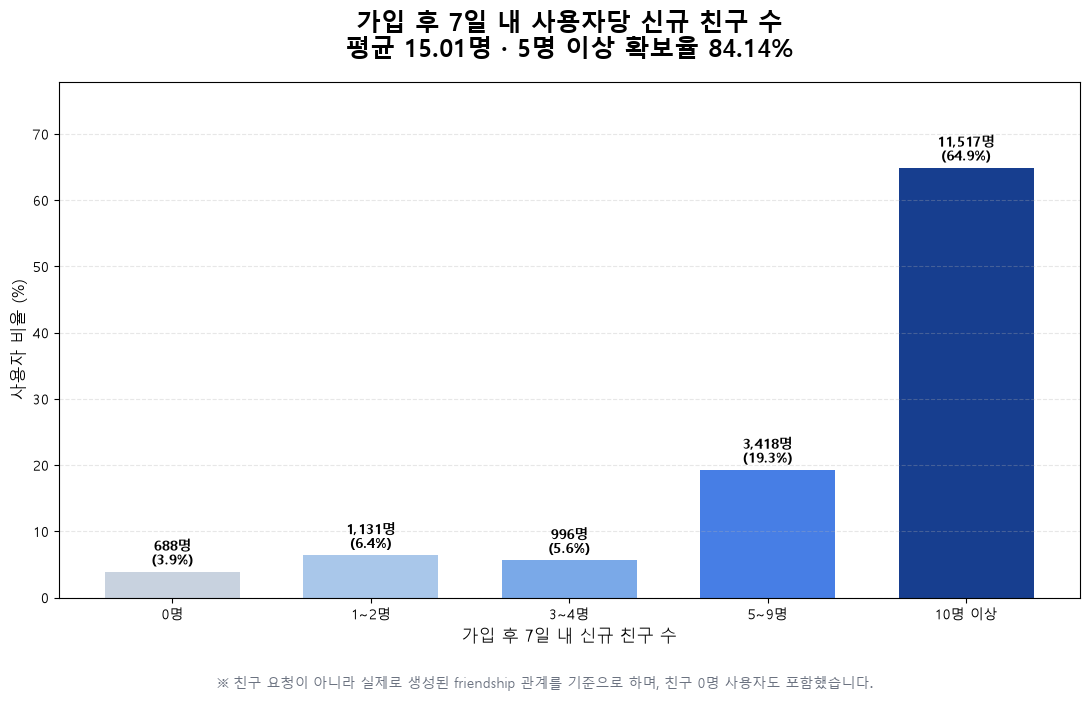

In [33]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = new_friends_df.sort_values(
    "group_order"
).copy()

average_count = float(
    plot_df["avg_new_friend_count"].iloc[0]
)

five_friend_rate = float(
    plot_df["five_friend_rate_percent"].iloc[0]
)

colors = [
    "#C8D2DF",
    "#A9C7EA",
    "#7AA9E8",
    "#477EE5",
    "#173E8F"
]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.bar(
    plot_df["friend_count_group"],
    plot_df["user_percent"],
    color=colors,
    width=0.68
)

ax.set_title(
    "가입 후 7일 내 사용자당 신규 친구 수\n"
    f"평균 {average_count:.2f}명 · 5명 이상 확보율 {five_friend_rate:.2f}%",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("가입 후 7일 내 신규 친구 수", fontsize=12)
ax.set_ylabel("사용자 비율 (%)", fontsize=12)
ax.set_ylim(0, plot_df["user_percent"].max() * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        (
            f"{int(row['user_count']):,}명\n"
            f"({float(row['user_percent']):.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.figtext(
    0.5,
    0.01,
    "※ 친구 요청이 아니라 실제로 생성된 friendship 관계를 기준으로 하며, 친구 0명 사용자도 포함했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [34]:
# 월별 신규 가입자 
new_signup_sql = """
-- 전체 및 월별 유효 신규 가입자 수
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic,
    created_at
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_new_users AS (
  SELECT
    u.user_id,
    u.created_at
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

monthly_signup AS (
  SELECT
    DATE_TRUNC(
      DATE(created_at, 'Asia/Seoul'),
      MONTH
    ) AS signup_month,

    COUNT(DISTINCT user_id) AS new_user_count

  FROM valid_new_users
  GROUP BY signup_month
),

monthly_with_previous AS (
  SELECT
    signup_month,
    new_user_count,

    LAG(new_user_count) OVER (
      ORDER BY signup_month
    ) AS previous_month_count,

    SUM(new_user_count) OVER () AS total_new_user_count

  FROM monthly_signup
)

SELECT
  signup_month,
  new_user_count,
  previous_month_count,
  total_new_user_count,

  new_user_count
    - previous_month_count AS increase_count,

  ROUND(
    SAFE_DIVIDE(
      new_user_count - previous_month_count,
      previous_month_count
    ) * 100,
    2
  ) AS growth_rate_percent

FROM monthly_with_previous
ORDER BY signup_month
"""

In [35]:
cost(new_signup_sql)

예상 스캔량: 0.640 MiB
예상 스캔량: 0.000625 GiB
월 1 TiB 무료 용량의 약 0.00006101%


0.0006247218698263168

In [36]:
new_signup_df = bq.query(
    new_signup_sql
).to_dataframe()

display(new_signup_df)

,signup_month,new_user_count,previous_month_count,total_new_user_count,increase_count,growth_rate_percent
0,2025-09-01,6302,<NA>,18001,<NA>,NaN
1,2025-10-01,867,6302,18001,-5435,-86.24
2,2025-11-01,848,867,18001,-19,-2.19
3,2025-12-01,877,848,18001,29,3.42
4,2026-01-01,469,877,18001,-408,-46.52
5,2026-02-01,461,469,18001,-8,-1.71
6,2026-03-01,3578,461,18001,3117,676.14
7,2026-04-01,1323,3578,18001,-2255,-63.02
8,2026-05-01,1420,1323,18001,97,7.33
9,2026-06-01,1066,1420,18001,-354,-24.93


In [38]:
import pandas as pd

if new_signup_df.empty:
    print("조회된 신규 가입자가 없습니다.")

else:
    total_new_users = int(
        new_signup_df["total_new_user_count"].iloc[0]
    )

    peak_row = new_signup_df.loc[
        new_signup_df["new_user_count"].idxmax()
    ]

    lowest_row = new_signup_df.loc[
        new_signup_df["new_user_count"].idxmin()
    ]

    print("[유효 신규 가입자 분석]")
    print(f"전체 유효 신규 가입자: {total_new_users:,}명")

    print(
        f"가입자가 가장 많았던 월: "
        f"{peak_row['signup_month']} | "
        f"{int(peak_row['new_user_count']):,}명"
    )

    print(
        f"가입자가 가장 적었던 월: "
        f"{lowest_row['signup_month']} | "
        f"{int(lowest_row['new_user_count']):,}명"
    )

    print()
    print("[월별 신규 가입자]")

    for _, row in new_signup_df.iterrows():
        month = row["signup_month"]
        count = int(row["new_user_count"])

        # 첫 달은 전월 데이터가 없어 결측값
        if (
            pd.isna(row["previous_month_count"])
            or pd.isna(row["increase_count"])
            or pd.isna(row["growth_rate_percent"])
        ):
            print(
                f"{month}: {count:,}명 | 최초 집계 월"
            )

        else:
            increase = int(row["increase_count"])
            growth = float(row["growth_rate_percent"])

            increase_sign = "+" if increase > 0 else ""
            growth_sign = "+" if growth > 0 else ""

            print(
                f"{month}: {count:,}명 | "
                f"전월 대비 {increase_sign}{increase:,}명 "
                f"({growth_sign}{growth:.2f}%)"
            )

[유효 신규 가입자 분석]
전체 유효 신규 가입자: 18,001명
가입자가 가장 많았던 월: 2025-09-01 | 6,302명
가입자가 가장 적었던 월: 2026-02-01 | 461명

[월별 신규 가입자]
2025-09-01: 6,302명 | 최초 집계 월
2025-10-01: 867명 | 전월 대비 -5,435명 (-86.24%)
2025-11-01: 848명 | 전월 대비 -19명 (-2.19%)
2025-12-01: 877명 | 전월 대비 +29명 (+3.42%)
2026-01-01: 469명 | 전월 대비 -408명 (-46.52%)
2026-02-01: 461명 | 전월 대비 -8명 (-1.71%)
2026-03-01: 3,578명 | 전월 대비 +3,117명 (+676.14%)
2026-04-01: 1,323명 | 전월 대비 -2,255명 (-63.02%)
2026-05-01: 1,420명 | 전월 대비 +97명 (+7.33%)
2026-06-01: 1,066명 | 전월 대비 -354명 (-24.93%)
2026-07-01: 790명 | 전월 대비 -276명 (-25.89%)


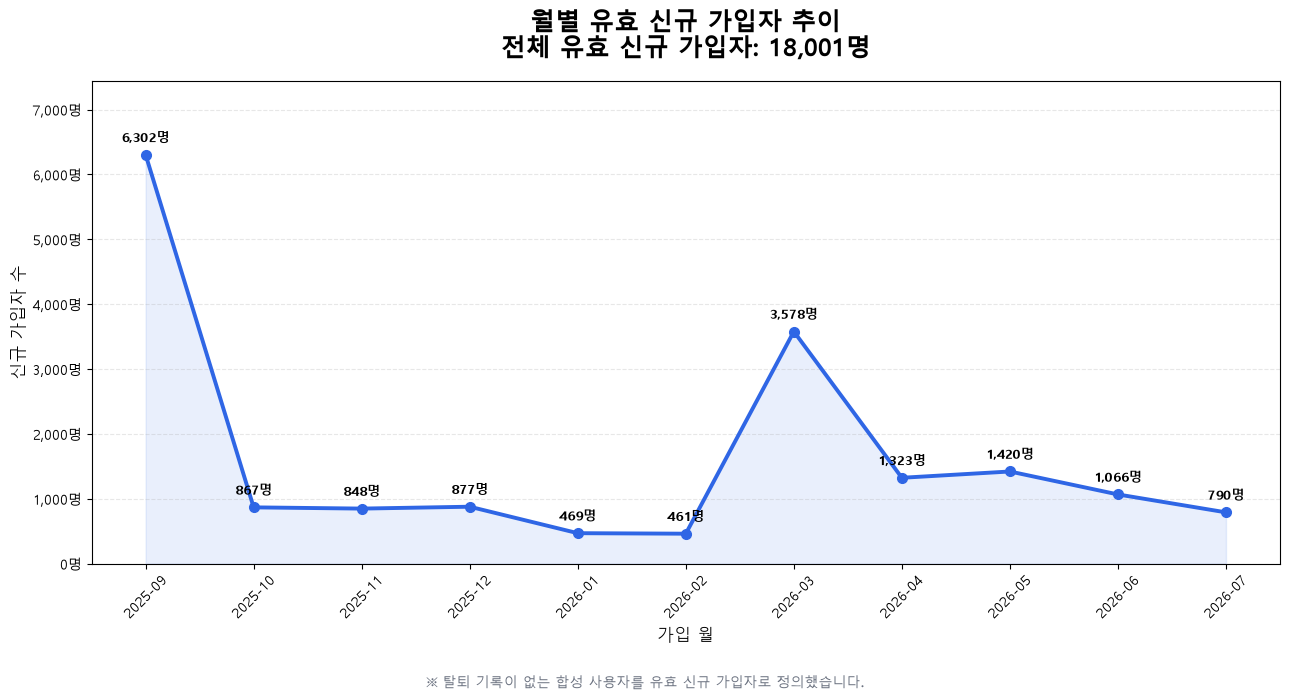

In [39]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = new_signup_df.copy()

plot_df["signup_month"] = pd.to_datetime(
    plot_df["signup_month"]
)

plot_df = plot_df.sort_values("signup_month")

month_labels = plot_df[
    "signup_month"
].dt.strftime("%Y-%m")

total_new_users = int(
    plot_df["total_new_user_count"].iloc[0]
)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    month_labels,
    plot_df["new_user_count"],
    color="#2F66E5",
    marker="o",
    linewidth=2.8,
    markersize=7
)

ax.fill_between(
    month_labels,
    plot_df["new_user_count"],
    color="#2F66E5",
    alpha=0.1
)

ax.set_title(
    f"월별 유효 신규 가입자 추이\n"
    f"전체 유효 신규 가입자: {total_new_users:,}명",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("가입 월", fontsize=12)
ax.set_ylabel("신규 가입자 수", fontsize=12)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{int(value):,}명"
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.tick_params(
    axis="x",
    rotation=45
)

y_offset = plot_df["new_user_count"].max() * 0.025

for x, value in zip(
    month_labels,
    plot_df["new_user_count"]
):
    ax.text(
        x,
        value + y_offset,
        f"{int(value):,}명",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_ylim(
    0,
    plot_df["new_user_count"].max() * 1.18
)

plt.figtext(
    0.5,
    0.01,
    "※ 탈퇴 기록이 없는 합성 사용자를 유효 신규 가입자로 정의했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [40]:
# 신고 처리
report_status_sql = """
-- 신고 처리 상태 및 미해결 신고 적체 현황
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

current_reports AS (
  SELECT
    id AS report_id,
    reporter_id,
    CAST(target_type AS STRING) AS target_type,
    CAST(status AS STRING) AS report_status,
    reviewed_by_admin_id,
    reviewed_at,
    created_at,
    updated_at
  FROM `ping-v2-503916.raw.report`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

report_base AS (
  SELECT
    r.*
  FROM current_reports AS r
  INNER JOIN current_users AS u
    ON r.reporter_id = u.user_id
  WHERE u.is_synthetic = TRUE
),

data_end AS (
  SELECT
    MAX(
      GREATEST(
        created_at,
        COALESCE(updated_at, created_at)
      )
    ) AS data_end_at
  FROM report_base
),

report_detail AS (
  SELECT
    r.*,

    ROUND(
      TIMESTAMP_DIFF(
        d.data_end_at,
        r.created_at,
        HOUR
      ) / 24.0,
      2
    ) AS elapsed_days,

    CASE
      WHEN r.report_status = 'PENDING'
        THEN '검토 전'
      WHEN r.report_status = 'REVIEWING'
        THEN '검토 중'
      WHEN r.report_status = 'ACTIONED'
        THEN '조치 완료'
      WHEN r.report_status = 'DISMISSED'
        THEN '기각'
      ELSE r.report_status
    END AS status_name,

    CASE
      WHEN r.report_status = 'PENDING' THEN 1
      WHEN r.report_status = 'REVIEWING' THEN 2
      WHEN r.report_status = 'ACTIONED' THEN 3
      WHEN r.report_status = 'DISMISSED' THEN 4
      ELSE 5
    END AS status_order

  FROM report_base AS r
  CROSS JOIN data_end AS d
),

status_count AS (
  SELECT
    report_status,
    status_name,
    status_order,
    COUNT(*) AS report_count
  FROM report_detail
  GROUP BY
    report_status,
    status_name,
    status_order
),

summary AS (
  SELECT
    COUNT(*) AS total_report_count,

    COUNTIF(
      report_status = 'PENDING'
    ) AS pending_report_count,

    COUNTIF(
      report_status = 'REVIEWING'
    ) AS reviewing_report_count,

    COUNTIF(
      report_status IN ('PENDING', 'REVIEWING')
    ) AS unresolved_report_count,

    COUNTIF(
      report_status IN ('ACTIONED', 'DISMISSED')
    ) AS resolved_report_count,

    ROUND(
      SAFE_DIVIDE(
        COUNTIF(
          report_status IN ('PENDING', 'REVIEWING')
        ),
        COUNT(*)
      ) * 100,
      2
    ) AS unresolved_rate_percent,

    ROUND(
      AVG(
        IF(
          report_status IN ('PENDING', 'REVIEWING'),
          elapsed_days,
          NULL
        )
      ),
      2
    ) AS avg_unresolved_days,

    ROUND(
      MAX(
        IF(
          report_status IN ('PENDING', 'REVIEWING'),
          elapsed_days,
          NULL
        )
      ),
      2
    ) AS max_unresolved_days,

    COUNTIF(
      report_status IN ('PENDING', 'REVIEWING')
      AND elapsed_days >= 3
    ) AS unresolved_over_3days,

    COUNTIF(
      report_status IN ('PENDING', 'REVIEWING')
      AND elapsed_days >= 7
    ) AS unresolved_over_7days

  FROM report_detail
)

SELECT
  s.report_status,
  s.status_name,
  s.status_order,
  s.report_count,

  ROUND(
    SAFE_DIVIDE(
      s.report_count,
      m.total_report_count
    ) * 100,
    2
  ) AS report_percent,

  m.total_report_count,
  m.pending_report_count,
  m.reviewing_report_count,
  m.unresolved_report_count,
  m.resolved_report_count,
  m.unresolved_rate_percent,
  m.avg_unresolved_days,
  m.max_unresolved_days,
  m.unresolved_over_3days,
  m.unresolved_over_7days

FROM status_count AS s
CROSS JOIN summary AS m
ORDER BY s.status_order
"""

In [41]:
cost(report_status_sql)

예상 스캔량: 1.916 MiB
예상 스캔량: 0.001871 GiB
월 1 TiB 무료 용량의 약 0.00018269%


0.0018707625567913055

In [42]:
report_status_df = bq.query(
    report_status_sql
).to_dataframe()

display(report_status_df)

,report_status,status_name,status_order,report_count,report_percent,total_report_count,pending_report_count,reviewing_report_count,unresolved_report_count,resolved_report_count,unresolved_rate_percent,avg_unresolved_days,max_unresolved_days,unresolved_over_3days,unresolved_over_7days
0,PENDING,검토 전,1,10140,32.64,31068,10140,0,10140,20928,32.64,123.79,325.88,9355,8886
1,ACTIONED,조치 완료,3,5178,16.67,31068,10140,0,10140,20928,32.64,123.79,325.88,9355,8886
2,DISMISSED,기각,4,15750,50.70,31068,10140,0,10140,20928,32.64,123.79,325.88,9355,8886


In [43]:
if report_status_df.empty:
    print("조회된 신고가 없습니다.")

else:
    summary = report_status_df.iloc[0]

    total_count = int(
        summary["total_report_count"]
    )

    pending_count = int(
        summary["pending_report_count"]
    )

    reviewing_count = int(
        summary["reviewing_report_count"]
    )

    unresolved_count = int(
        summary["unresolved_report_count"]
    )

    resolved_count = int(
        summary["resolved_report_count"]
    )

    unresolved_rate = float(
        summary["unresolved_rate_percent"]
    )

    avg_days = float(
        summary["avg_unresolved_days"]
    )

    max_days = float(
        summary["max_unresolved_days"]
    )

    over_3days = int(
        summary["unresolved_over_3days"]
    )

    over_7days = int(
        summary["unresolved_over_7days"]
    )

    print("[신고 처리 현황]")
    print(f"전체 신고: {total_count:,}건")

    print(
        f"검토를 시작하지 않은 신고(PENDING): "
        f"{pending_count:,}건"
    )

    print(
        f"현재 검토 중인 신고(REVIEWING): "
        f"{reviewing_count:,}건"
    )

    print(
        f"처리가 끝나지 않은 신고: "
        f"{unresolved_count:,}건 "
        f"({unresolved_rate:.2f}%)"
    )

    print(f"처리 완료 신고: {resolved_count:,}건")

    print()
    print("[미해결 신고 적체 현황]")

    print(
        f"평균 미해결 기간: {avg_days:.2f}일"
    )

    print(
        f"가장 오래된 미해결 신고: {max_days:.2f}일"
    )

    print(
        f"3일 이상 미해결: {over_3days:,}건"
    )

    print(
        f"7일 이상 미해결: {over_7days:,}건"
    )

    print()
    print("[상태별 신고]")

    for _, row in report_status_df.iterrows():
        print(
            f"{row['status_name']}: "
            f"{int(row['report_count']):,}건 "
            f"({float(row['report_percent']):.2f}%)"
        )

[신고 처리 현황]
전체 신고: 31,068건
검토를 시작하지 않은 신고(PENDING): 10,140건
현재 검토 중인 신고(REVIEWING): 0건
처리가 끝나지 않은 신고: 10,140건 (32.64%)
처리 완료 신고: 20,928건

[미해결 신고 적체 현황]
평균 미해결 기간: 123.79일
가장 오래된 미해결 신고: 325.88일
3일 이상 미해결: 9,355건
7일 이상 미해결: 8,886건

[상태별 신고]
검토 전: 10,140건 (32.64%)
조치 완료: 5,178건 (16.67%)
기각: 15,750건 (50.70%)


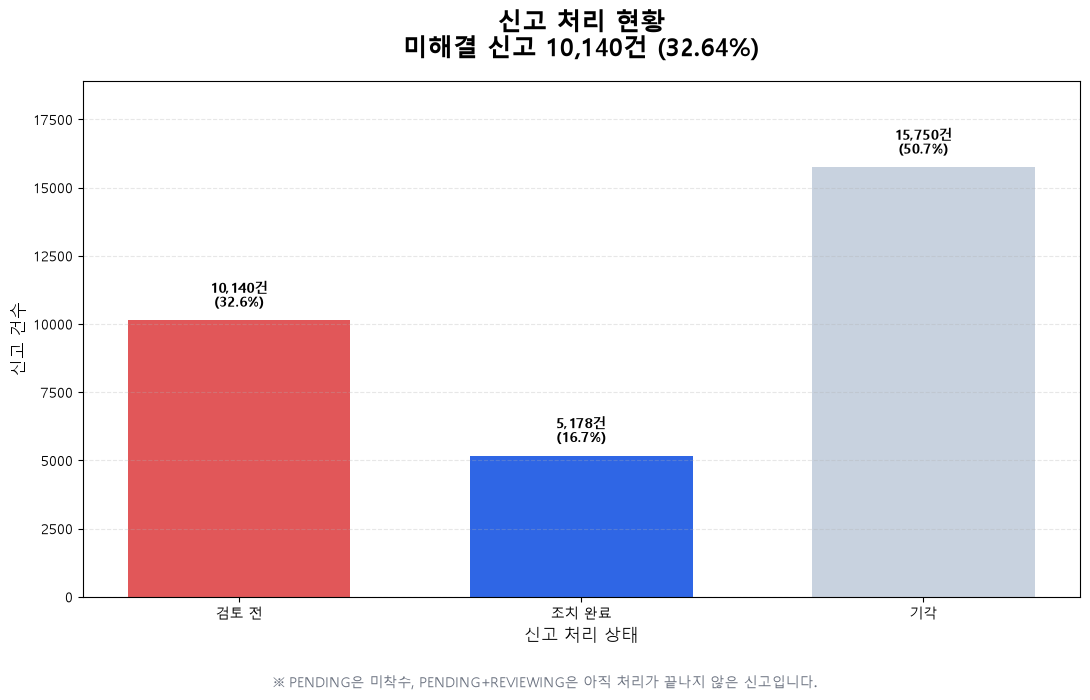

In [44]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = report_status_df.sort_values(
    "status_order"
).copy()

colors = {
    "검토 전": "#E15759",
    "검토 중": "#F2A541",
    "조치 완료": "#2F66E5",
    "기각": "#C8D2DF"
}

bar_colors = [
    colors.get(status, "#9CA3AF")
    for status in plot_df["status_name"]
]

unresolved_count = int(
    plot_df["unresolved_report_count"].iloc[0]
)

unresolved_rate = float(
    plot_df["unresolved_rate_percent"].iloc[0]
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.bar(
    plot_df["status_name"],
    plot_df["report_count"],
    color=bar_colors,
    width=0.65
)

ax.set_title(
    "신고 처리 현황\n"
    f"미해결 신고 {unresolved_count:,}건 "
    f"({unresolved_rate:.2f}%)",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("신고 처리 상태", fontsize=12)
ax.set_ylabel("신고 건수", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)

y_offset = max(plot_df["report_count"].max() * 0.025, 0.5)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_offset,
        (
            f"{int(row['report_count']):,}건\n"
            f"({float(row['report_percent']):.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylim(
    0,
    plot_df["report_count"].max() * 1.2
)

plt.figtext(
    0.5,
    0.01,
    "※ PENDING은 미착수, PENDING+REVIEWING은 아직 처리가 끝나지 않은 신고입니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [45]:
# 월별 하트 적립, 소비
heart_flow_sql = """
-- 월별 하트 적립·충전·소비 현황
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_transactions AS (
  SELECT
    id AS transaction_id,
    user_id,
    type_code,
    delta,
    balance_after,
    created_at
  FROM `ping-v2-503916.raw.heart_transaction`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

valid_transactions AS (
  SELECT
    t.*
  FROM current_transactions AS t
  INNER JOIN valid_users AS u
    ON t.user_id = u.user_id
),

monthly_flow AS (
  SELECT
    DATE_TRUNC(
      DATE(created_at, 'Asia/Seoul'),
      MONTH
    ) AS transaction_month,

    COUNT(*) AS transaction_count,
    COUNT(DISTINCT user_id) AS transaction_user_count,

    -- 전체 하트 유입
    SUM(
      IF(delta > 0, delta, 0)
    ) AS inflow_heart,

    -- 가입 시 기본 지급
    SUM(
      IF(type_code = 'SIGNUP_GRANT', delta, 0)
    ) AS signup_grant_heart,

    -- 투표·광고·이벤트 등 무료 활동 적립
    SUM(
      IF(
        type_code IN (
          'VOTE_REWARD',
          'AD_REWARD',
          'EVENT_GRANT'
        ),
        delta,
        0
      )
    ) AS activity_earned_heart,

    -- 하트 상품 충전
    SUM(
      IF(type_code = 'TOPUP', delta, 0)
    ) AS topup_heart,

    -- 전체 하트 유출을 양수로 표시
    SUM(
      IF(delta < 0, -delta, 0)
    ) AS outflow_heart,

    -- 힌트 구매 소비
    SUM(
      IF(
        type_code = 'HINT_PURCHASE',
        -delta,
        0
      )
    ) AS hint_spent_heart,

    -- 답장 기능 소비
    SUM(
      IF(
        type_code = 'VOTE_REPLY',
        -delta,
        0
      )
    ) AS reply_spent_heart,

    -- 사용자의 실제 기능 소비
    SUM(
      IF(
        type_code IN (
          'HINT_PURCHASE',
          'VOTE_REPLY'
        ),
        -delta,
        0
      )
    ) AS user_spent_heart,

    -- 적립 및 소비를 반영한 월별 순증감
    SUM(delta) AS net_heart_change

  FROM valid_transactions
  GROUP BY transaction_month
),

total_summary AS (
  SELECT
    COUNT(*) AS total_transaction_count,
    COUNT(DISTINCT user_id) AS total_transaction_user_count,

    SUM(
      IF(delta > 0, delta, 0)
    ) AS total_inflow_heart,

    SUM(
      IF(delta < 0, -delta, 0)
    ) AS total_outflow_heart,

    SUM(
      IF(
        type_code IN (
          'HINT_PURCHASE',
          'VOTE_REPLY'
        ),
        -delta,
        0
      )
    ) AS total_user_spent_heart,

    SUM(delta) AS total_net_heart_change

  FROM valid_transactions
)

SELECT
  m.*,

  t.total_transaction_count,
  t.total_transaction_user_count,
  t.total_inflow_heart,
  t.total_outflow_heart,
  t.total_user_spent_heart,
  t.total_net_heart_change,

  ROUND(
    SAFE_DIVIDE(
      t.total_user_spent_heart,
      t.total_inflow_heart
    ) * 100,
    2
  ) AS heart_consumption_rate_percent

FROM monthly_flow AS m
CROSS JOIN total_summary AS t
ORDER BY transaction_month
"""

In [46]:
cost(heart_flow_sql)

예상 스캔량: 1,032.157 MiB
예상 스캔량: 1.007966 GiB
월 1 TiB 무료 용량의 약 0.09843416%


1.0079657742753625

In [47]:
heart_flow_df = bq.query(
    heart_flow_sql
).to_dataframe()

display(heart_flow_df)

,transaction_month,transaction_count,transaction_user_count,inflow_heart,signup_grant_heart,activity_earned_heart,topup_heart,outflow_heart,hint_spent_heart,reply_spent_heart,user_spent_heart,net_heart_change,total_transaction_count,total_transaction_user_count,total_inflow_heart,total_outflow_heart,total_user_spent_heart,total_net_heart_change,heart_consumption_rate_percent
0,2025-09-01,1822377,13834,7194438,1890600,5015166,287772,3729540,3047660,681880,3729540,3464898,16245059,18001,66932637,31946540,31946540,34986097,47.73
1,2025-10-01,1315984,12290,4699157,260100,3679406,757401,2440400,1975680,464720,2440400,2258757,16245059,18001,66932637,31946540,31946540,34986097,47.73
2,2025-11-01,1281245,11489,4550741,254400,3576874,717817,2399740,1951720,448020,2399740,2151001,16245059,18001,66932637,31946540,31946540,34986097,47.73
3,2025-12-01,787345,10699,3293728,263100,2202953,824725,1439280,1171120,268160,1439280,1854448,16245059,18001,66932637,31946540,31946540,34986097,47.73
4,2026-01-01,527158,9828,2632895,140700,1487040,1001805,903000,742600,160400,903000,1729895,16245059,18001,66932637,31946540,31946540,34986097,47.73
5,2026-02-01,443565,10237,2355055,138300,1250750,962405,761520,629280,132240,761520,1593535,16245059,18001,66932637,31946540,31946540,34986097,47.73
6,2026-03-01,2488986,14989,9392130,1073400,6881125,1431655,5065900,4133780,932120,5065900,4326230,16245059,18001,66932637,31946540,31946540,34986097,47.73
7,2026-04-01,2063426,14480,7965276,396900,5728028,1833348,4086020,3291300,794720,4086020,3879256,16245059,18001,66932637,31946540,31946540,34986097,47.73
8,2026-05-01,2398473,14337,9489370,426000,6640644,2415476,4830160,3909380,920780,4830160,4659210,16245059,18001,66932637,31946540,31946540,34986097,47.73
9,2026-06-01,1706338,13460,8104418,319800,4741870,3031498,3347840,2700960,646880,3347840,4756578,16245059,18001,66932637,31946540,31946540,34986097,47.73


In [48]:
if heart_flow_df.empty:
    print("조회된 하트 거래가 없습니다.")

else:
    summary = heart_flow_df.iloc[0]

    total_transactions = int(
        summary["total_transaction_count"]
    )

    transaction_users = int(
        summary["total_transaction_user_count"]
    )

    total_inflow = int(
        summary["total_inflow_heart"]
    )

    total_outflow = int(
        summary["total_outflow_heart"]
    )

    total_user_spent = int(
        summary["total_user_spent_heart"]
    )

    total_net_change = int(
        summary["total_net_heart_change"]
    )

    consumption_rate = float(
        summary["heart_consumption_rate_percent"]
    )

    print("[하트 적립·소비 현황]")
    print(f"하트 거래 사용자: {transaction_users:,}명")
    print(f"전체 하트 거래: {total_transactions:,}건")
    print(f"전체 하트 유입: {total_inflow:,}하트")
    print(f"전체 하트 유출: {total_outflow:,}하트")

    print(
        f"힌트·답장 기능 소비: "
        f"{total_user_spent:,}하트"
    )

    print(
        f"전체 하트 순증감: "
        f"{total_net_change:+,}하트"
    )

    print(
        f"하트 소비율: {consumption_rate:.2f}%"
    )

    print()
    print("[월별 하트 흐름]")

    for _, row in heart_flow_df.iterrows():
        print(
            f"{row['transaction_month']}: "
            f"유입 {int(row['inflow_heart']):,} | "
            f"소비 {int(row['user_spent_heart']):,} | "
            f"순증감 {int(row['net_heart_change']):+,}"
        )

[하트 적립·소비 현황]
하트 거래 사용자: 18,001명
전체 하트 거래: 16,245,059건
전체 하트 유입: 66,932,637하트
전체 하트 유출: 31,946,540하트
힌트·답장 기능 소비: 31,946,540하트
전체 하트 순증감: +34,986,097하트
하트 소비율: 47.73%

[월별 하트 흐름]
2025-09-01: 유입 7,194,438 | 소비 3,729,540 | 순증감 +3,464,898
2025-10-01: 유입 4,699,157 | 소비 2,440,400 | 순증감 +2,258,757
2025-11-01: 유입 4,550,741 | 소비 2,399,740 | 순증감 +2,151,001
2025-12-01: 유입 3,293,728 | 소비 1,439,280 | 순증감 +1,854,448
2026-01-01: 유입 2,632,895 | 소비 903,000 | 순증감 +1,729,895
2026-02-01: 유입 2,355,055 | 소비 761,520 | 순증감 +1,593,535
2026-03-01: 유입 9,392,130 | 소비 5,065,900 | 순증감 +4,326,230
2026-04-01: 유입 7,965,276 | 소비 4,086,020 | 순증감 +3,879,256
2026-05-01: 유입 9,489,370 | 소비 4,830,160 | 순증감 +4,659,210
2026-06-01: 유입 8,104,418 | 소비 3,347,840 | 순증감 +4,756,578
2026-07-01: 유입 7,255,429 | 소비 2,943,140 | 순증감 +4,312,289


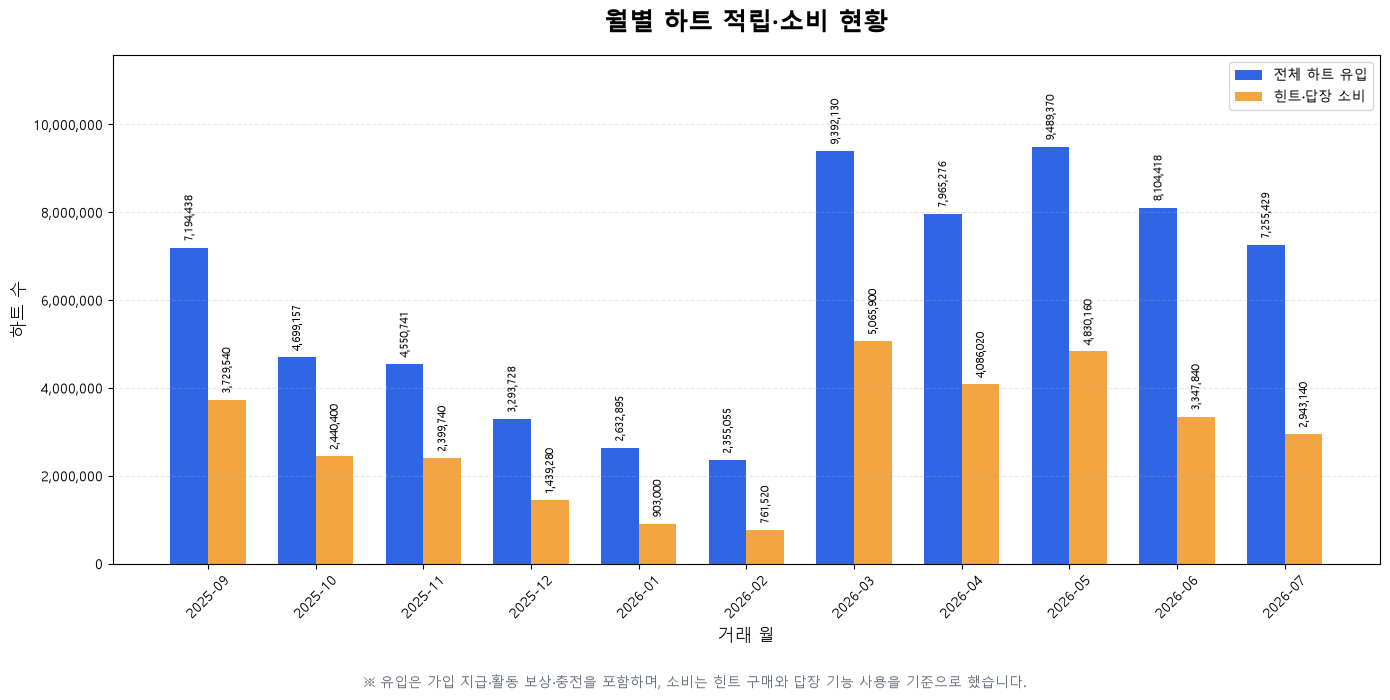

In [49]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = heart_flow_df.copy()

plot_df["transaction_month"] = pd.to_datetime(
    plot_df["transaction_month"]
)

plot_df = plot_df.sort_values(
    "transaction_month"
)

month_labels = plot_df[
    "transaction_month"
].dt.strftime("%Y-%m")

x = range(len(plot_df))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

inflow_bars = ax.bar(
    [index - bar_width / 2 for index in x],
    plot_df["inflow_heart"],
    width=bar_width,
    color="#2F66E5",
    label="전체 하트 유입"
)

spent_bars = ax.bar(
    [index + bar_width / 2 for index in x],
    plot_df["user_spent_heart"],
    width=bar_width,
    color="#F2A541",
    label="힌트·답장 소비"
)

ax.set_title(
    "월별 하트 적립·소비 현황",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("거래 월", fontsize=12)
ax.set_ylabel("하트 수", fontsize=12)

ax.set_xticks(list(x))
ax.set_xticklabels(
    month_labels,
    rotation=45
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{int(value):,}"
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

max_value = max(
    plot_df["inflow_heart"].max(),
    plot_df["user_spent_heart"].max()
)

label_offset = max_value * 0.015

for bars in [inflow_bars, spent_bars]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + label_offset,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_ylim(0, max_value * 1.22)

plt.figtext(
    0.5,
    0.01,
    "※ 유입은 가입 지급·활동 보상·충전을 포함하며, 소비는 힌트 구매와 답장 기능 사용을 기준으로 했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [50]:
# 일별 접속 사용자 수 쿼리
service_access_sql = """
-- 전체 접속 경험 사용자와 일별 접속 사용자 수(DAU)
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_sessions AS (
  SELECT
    id AS session_id,
    user_id,
    started_at,
    ended_at
  FROM `ping-v2-503916.raw.user_session`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
    AND started_at IS NOT NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

valid_sessions AS (
  SELECT
    s.session_id,
    s.user_id,
    s.started_at,
    s.ended_at
  FROM current_sessions AS s
  INNER JOIN valid_users AS u
    ON s.user_id = u.user_id
),

daily_access AS (
  SELECT
    DATE(
      started_at,
      'Asia/Seoul'
    ) AS access_date,

    COUNT(DISTINCT user_id) AS daily_active_user_count,
    COUNT(*) AS session_count

  FROM valid_sessions
  GROUP BY access_date
),

summary AS (
  SELECT
    (SELECT COUNT(*) FROM valid_users)
      AS total_valid_user_count,

    COUNT(DISTINCT user_id)
      AS total_access_user_count,

    COUNT(*) AS total_session_count

  FROM valid_sessions
)

SELECT
  d.access_date,
  d.daily_active_user_count,
  d.session_count,

  ROUND(
    SAFE_DIVIDE(
      d.session_count,
      d.daily_active_user_count
    ),
    2
  ) AS sessions_per_active_user,

  s.total_valid_user_count,
  s.total_access_user_count,
  s.total_session_count,

  s.total_valid_user_count
    - s.total_access_user_count
    AS no_access_user_count,

  ROUND(
    SAFE_DIVIDE(
      s.total_access_user_count,
      s.total_valid_user_count
    ) * 100,
    2
  ) AS access_experience_rate_percent

FROM daily_access AS d
CROSS JOIN summary AS s
ORDER BY d.access_date
"""

In [51]:
cost(service_access_sql)

예상 스캔량: 37.223 MiB
예상 스캔량: 0.036351 GiB
월 1 TiB 무료 용량의 약 0.00354989%


0.0363509189337492

In [52]:
service_access_df = bq.query(
    service_access_sql
).to_dataframe()

display(service_access_df)

,access_date,daily_active_user_count,session_count,sessions_per_active_user,total_valid_user_count,total_access_user_count,total_session_count,no_access_user_count,access_experience_rate_percent
0,2025-09-01,87,144,1.66,18001,16855,900459,1146,93.63
1,2025-09-02,207,397,1.92,18001,16855,900459,1146,93.63
2,2025-09-03,279,582,2.09,18001,16855,900459,1146,93.63
3,2025-09-04,375,846,2.26,18001,16855,900459,1146,93.63
4,2025-09-05,438,1067,2.44,18001,16855,900459,1146,93.63
...,...,...,...,...,...,...,...,...,...
321,2026-07-19,734,3931,5.36,18001,16855,900459,1146,93.63
322,2026-07-20,767,4201,5.48,18001,16855,900459,1146,93.63
323,2026-07-21,744,4131,5.55,18001,16855,900459,1146,93.63
324,2026-07-22,719,3454,4.80,18001,16855,900459,1146,93.63


In [53]:
if service_access_df.empty:
    print("조회된 접속 기록이 없습니다.")

else:
    summary = service_access_df.iloc[0]

    total_valid_users = int(
        summary["total_valid_user_count"]
    )

    total_access_users = int(
        summary["total_access_user_count"]
    )

    no_access_users = int(
        summary["no_access_user_count"]
    )

    total_sessions = int(
        summary["total_session_count"]
    )

    access_rate = float(
        summary["access_experience_rate_percent"]
    )

    average_dau = service_access_df[
        "daily_active_user_count"
    ].mean()

    peak_row = service_access_df.loc[
        service_access_df[
            "daily_active_user_count"
        ].idxmax()
    ]

    print("[서비스 접속 사용자 분석]")
    print(f"전체 유효 사용자: {total_valid_users:,}명")

    print(
        f"한 번 이상 접속한 사용자: "
        f"{total_access_users:,}명 "
        f"({access_rate:.2f}%)"
    )

    print(
        f"접속 기록이 없는 사용자: "
        f"{no_access_users:,}명 "
        f"({100 - access_rate:.2f}%)"
    )

    print(f"전체 접속 세션: {total_sessions:,}건")
    print(f"일평균 접속 사용자(평균 DAU): {average_dau:,.1f}명")

    print(
        f"DAU가 가장 높았던 날: "
        f"{peak_row['access_date']} | "
        f"{int(peak_row['daily_active_user_count']):,}명"
    )

[서비스 접속 사용자 분석]
전체 유효 사용자: 18,001명
한 번 이상 접속한 사용자: 16,855명 (93.63%)
접속 기록이 없는 사용자: 1,146명 (6.37%)
전체 접속 세션: 900,459건
일평균 접속 사용자(평균 DAU): 730.2명
DAU가 가장 높았던 날: 2025-09-30 | 1,972명


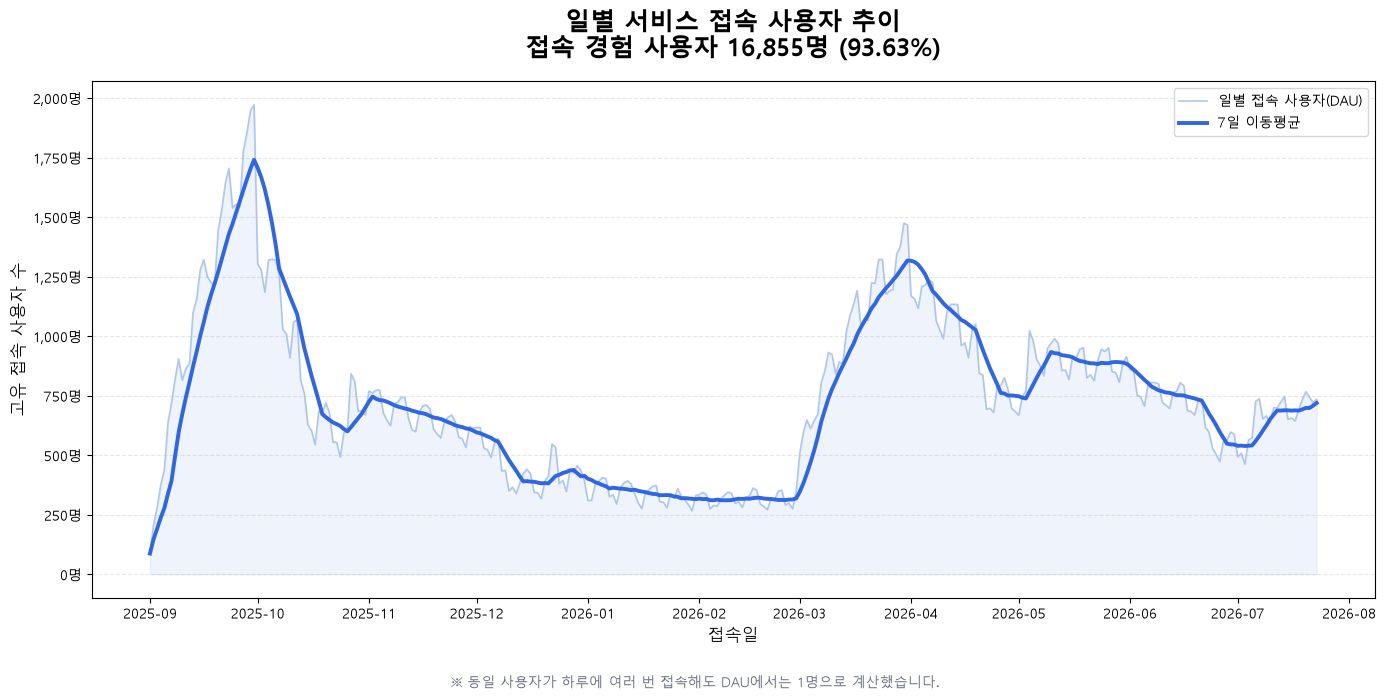

In [54]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = service_access_df.copy()

plot_df["access_date"] = pd.to_datetime(
    plot_df["access_date"]
)

plot_df = plot_df.sort_values("access_date")

# 일별 변동을 부드럽게 보기 위한 7일 이동평균
plot_df["dau_7day_average"] = (
    plot_df["daily_active_user_count"]
    .rolling(window=7, min_periods=1)
    .mean()
)

total_access_users = int(
    plot_df["total_access_user_count"].iloc[0]
)

access_rate = float(
    plot_df["access_experience_rate_percent"].iloc[0]
)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    plot_df["access_date"],
    plot_df["daily_active_user_count"],
    color="#9BB9E5",
    linewidth=1.2,
    alpha=0.75,
    label="일별 접속 사용자(DAU)"
)

ax.plot(
    plot_df["access_date"],
    plot_df["dau_7day_average"],
    color="#2F66E5",
    linewidth=2.8,
    label="7일 이동평균"
)

ax.fill_between(
    plot_df["access_date"],
    plot_df["daily_active_user_count"],
    color="#2F66E5",
    alpha=0.08
)

ax.set_title(
    "일별 서비스 접속 사용자 추이\n"
    f"접속 경험 사용자 {total_access_users:,}명 "
    f"({access_rate:.2f}%)",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("접속일", fontsize=12)
ax.set_ylabel("고유 접속 사용자 수", fontsize=12)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{int(value):,}명"
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.figtext(
    0.5,
    0.01,
    "※ 동일 사용자가 하루에 여러 번 접속해도 DAU에서는 1명으로 계산했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [55]:
# 무료 지급, 유료 충전, 소비 쿼리
heart_source_flow_sql = """
-- 월별 무료 지급·실제 결제 충전·소비 하트 비교
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_purchases AS (
  SELECT
    id AS purchase_id,
    status,
    store_transaction_id
  FROM `ping-v2-503916.raw.heart_purchase`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

current_transactions AS (
  SELECT
    id AS transaction_id,
    user_id,
    type_code,
    delta,
    purchase_id,
    created_at
  FROM `ping-v2-503916.raw.heart_transaction`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

transaction_base AS (
  SELECT
    t.*,

    -- 성공한 실제 결제 충전인지 판정
    CASE
      WHEN t.type_code = 'TOPUP'
        AND p.status = 'SUCCESS'
        AND NOT STARTS_WITH(
          COALESCE(p.store_transaction_id, ''),
          'MVP-STUB-'
        )
      THEN TRUE
      ELSE FALSE
    END AS is_real_paid_topup,

    -- 실제 결제가 아닌 스텁 충전
    CASE
      WHEN t.type_code = 'TOPUP'
        AND STARTS_WITH(
          COALESCE(p.store_transaction_id, ''),
          'MVP-STUB-'
        )
      THEN TRUE
      ELSE FALSE
    END AS is_stub_topup

  FROM current_transactions AS t
  INNER JOIN valid_users AS u
    ON t.user_id = u.user_id
  LEFT JOIN current_purchases AS p
    ON t.purchase_id = p.purchase_id
),

monthly_flow AS (
  SELECT
    DATE_TRUNC(
      DATE(created_at, 'Asia/Seoul'),
      MONTH
    ) AS transaction_month,

    -- 가입·투표·광고·이벤트로 무료 지급된 하트
    SUM(
      IF(
        type_code IN (
          'SIGNUP_GRANT',
          'VOTE_REWARD',
          'AD_REWARD',
          'EVENT_GRANT'
        )
        AND delta > 0,
        delta,
        0
      )
    ) AS free_received_heart,

    -- 성공한 실제 결제로 충전된 하트
    SUM(
      IF(
        is_real_paid_topup
        AND delta > 0,
        delta,
        0
      )
    ) AS paid_topup_heart,

    -- MVP 테스트·스텁 충전
    SUM(
      IF(
        is_stub_topup
        AND delta > 0,
        delta,
        0
      )
    ) AS stub_topup_heart,

    -- 운영자 지급·조정 등
    SUM(
      IF(
        type_code = 'ADMIN_ADJUST'
        AND delta > 0,
        delta,
        0
      )
    ) AS admin_adjust_heart,

    -- 힌트·답장 기능 소비
    SUM(
      IF(
        type_code IN (
          'HINT_PURCHASE',
          'VOTE_REPLY'
        )
        AND delta < 0,
        -delta,
        0
      )
    ) AS user_spent_heart

  FROM transaction_base
  GROUP BY transaction_month
),

total_summary AS (
  SELECT
    SUM(free_received_heart) AS total_free_received_heart,
    SUM(paid_topup_heart) AS total_paid_topup_heart,
    SUM(stub_topup_heart) AS total_stub_topup_heart,
    SUM(admin_adjust_heart) AS total_admin_adjust_heart,
    SUM(user_spent_heart) AS total_user_spent_heart
  FROM monthly_flow
)

SELECT
  m.*,

  t.total_free_received_heart,
  t.total_paid_topup_heart,
  t.total_stub_topup_heart,
  t.total_admin_adjust_heart,
  t.total_user_spent_heart,

  ROUND(
    SAFE_DIVIDE(
      m.free_received_heart,
      m.free_received_heart + m.paid_topup_heart
    ) * 100,
    2
  ) AS monthly_free_share_percent,

  ROUND(
    SAFE_DIVIDE(
      m.paid_topup_heart,
      m.free_received_heart + m.paid_topup_heart
    ) * 100,
    2
  ) AS monthly_paid_share_percent

FROM monthly_flow AS m
CROSS JOIN total_summary AS t
ORDER BY transaction_month
"""

In [56]:
cost(heart_source_flow_sql)

예상 스캔량: 1,032.854 MiB
예상 스캔량: 1.008646 GiB
월 1 TiB 무료 용량의 약 0.09850060%


1.008646166883409

In [58]:
heart_source_df = bq.query(
    heart_source_flow_sql
).to_dataframe()

display(heart_source_df)

,transaction_month,free_received_heart,paid_topup_heart,stub_topup_heart,admin_adjust_heart,user_spent_heart,total_free_received_heart,total_paid_topup_heart,total_stub_topup_heart,total_admin_adjust_heart,total_user_spent_heart,monthly_free_share_percent,monthly_paid_share_percent
0,2025-09-01,6905766,287772,0,900,3729540,50499603,16376834,0,56200,31946540,96.00,4.00
1,2025-10-01,3939506,757401,0,2250,2440400,50499603,16376834,0,56200,31946540,83.87,16.13
2,2025-11-01,3831274,717817,0,1650,2399740,50499603,16376834,0,56200,31946540,84.22,15.78
3,2025-12-01,2466053,824725,0,2950,1439280,50499603,16376834,0,56200,31946540,74.94,25.06
4,2026-01-01,1627740,1001805,0,3350,903000,50499603,16376834,0,56200,31946540,61.90,38.10
5,2026-02-01,1389050,962405,0,3600,761520,50499603,16376834,0,56200,31946540,59.07,40.93
6,2026-03-01,7954525,1431655,0,5950,5065900,50499603,16376834,0,56200,31946540,84.75,15.25
7,2026-04-01,6124928,1833348,0,7000,4086020,50499603,16376834,0,56200,31946540,76.96,23.04
8,2026-05-01,7066644,2415476,0,7250,4830160,50499603,16376834,0,56200,31946540,74.53,25.47
9,2026-06-01,5061670,3031498,0,11250,3347840,50499603,16376834,0,56200,31946540,62.54,37.46


In [59]:
if heart_source_df.empty:
    print("조회된 하트 거래가 없습니다.")

else:
    summary = heart_source_df.iloc[0]

    total_free = int(
        summary["total_free_received_heart"]
    )

    total_paid = int(
        summary["total_paid_topup_heart"]
    )

    total_stub = int(
        summary["total_stub_topup_heart"]
    )

    total_admin = int(
        summary["total_admin_adjust_heart"]
    )

    total_spent = int(
        summary["total_user_spent_heart"]
    )

    real_inflow = total_free + total_paid

    free_share = (
        total_free / real_inflow * 100
        if real_inflow > 0
        else 0
    )

    paid_share = (
        total_paid / real_inflow * 100
        if real_inflow > 0
        else 0
    )

    print("[하트 유입 출처 분석]")
    print(f"무료 지급 하트: {total_free:,}개 ({free_share:.2f}%)")
    print(f"실제 결제 충전 하트: {total_paid:,}개 ({paid_share:.2f}%)")
    print(f"힌트·답장 소비 하트: {total_spent:,}개")
    print(f"운영자 조정 하트: {total_admin:,}개")

    print(
        f"분석에서 제외한 MVP 스텁 충전: "
        f"{total_stub:,}개"
    )

    print()
    print("[월별 무료 지급·결제 충전]")

    for _, row in heart_source_df.iterrows():
        print(
            f"{row['transaction_month']}: "
            f"무료 {int(row['free_received_heart']):,}개 "
            f"({float(row['monthly_free_share_percent']):.2f}%) | "
            f"결제 {int(row['paid_topup_heart']):,}개 "
            f"({float(row['monthly_paid_share_percent']):.2f}%) | "
            f"소비 {int(row['user_spent_heart']):,}개"
        )

[하트 유입 출처 분석]
무료 지급 하트: 50,499,603개 (75.51%)
실제 결제 충전 하트: 16,376,834개 (24.49%)
힌트·답장 소비 하트: 31,946,540개
운영자 조정 하트: 56,200개
분석에서 제외한 MVP 스텁 충전: 0개

[월별 무료 지급·결제 충전]
2025-09-01: 무료 6,905,766개 (96.00%) | 결제 287,772개 (4.00%) | 소비 3,729,540개
2025-10-01: 무료 3,939,506개 (83.87%) | 결제 757,401개 (16.13%) | 소비 2,440,400개
2025-11-01: 무료 3,831,274개 (84.22%) | 결제 717,817개 (15.78%) | 소비 2,399,740개
2025-12-01: 무료 2,466,053개 (74.94%) | 결제 824,725개 (25.06%) | 소비 1,439,280개
2026-01-01: 무료 1,627,740개 (61.90%) | 결제 1,001,805개 (38.10%) | 소비 903,000개
2026-02-01: 무료 1,389,050개 (59.07%) | 결제 962,405개 (40.93%) | 소비 761,520개
2026-03-01: 무료 7,954,525개 (84.75%) | 결제 1,431,655개 (15.25%) | 소비 5,065,900개
2026-04-01: 무료 6,124,928개 (76.96%) | 결제 1,833,348개 (23.04%) | 소비 4,086,020개
2026-05-01: 무료 7,066,644개 (74.53%) | 결제 2,415,476개 (25.47%) | 소비 4,830,160개
2026-06-01: 무료 5,061,670개 (62.54%) | 결제 3,031,498개 (37.46%) | 소비 3,347,840개
2026-07-01: 무료 4,132,447개 (57.04%) | 결제 3,112,932개 (42.96%) | 소비 2,943,140개


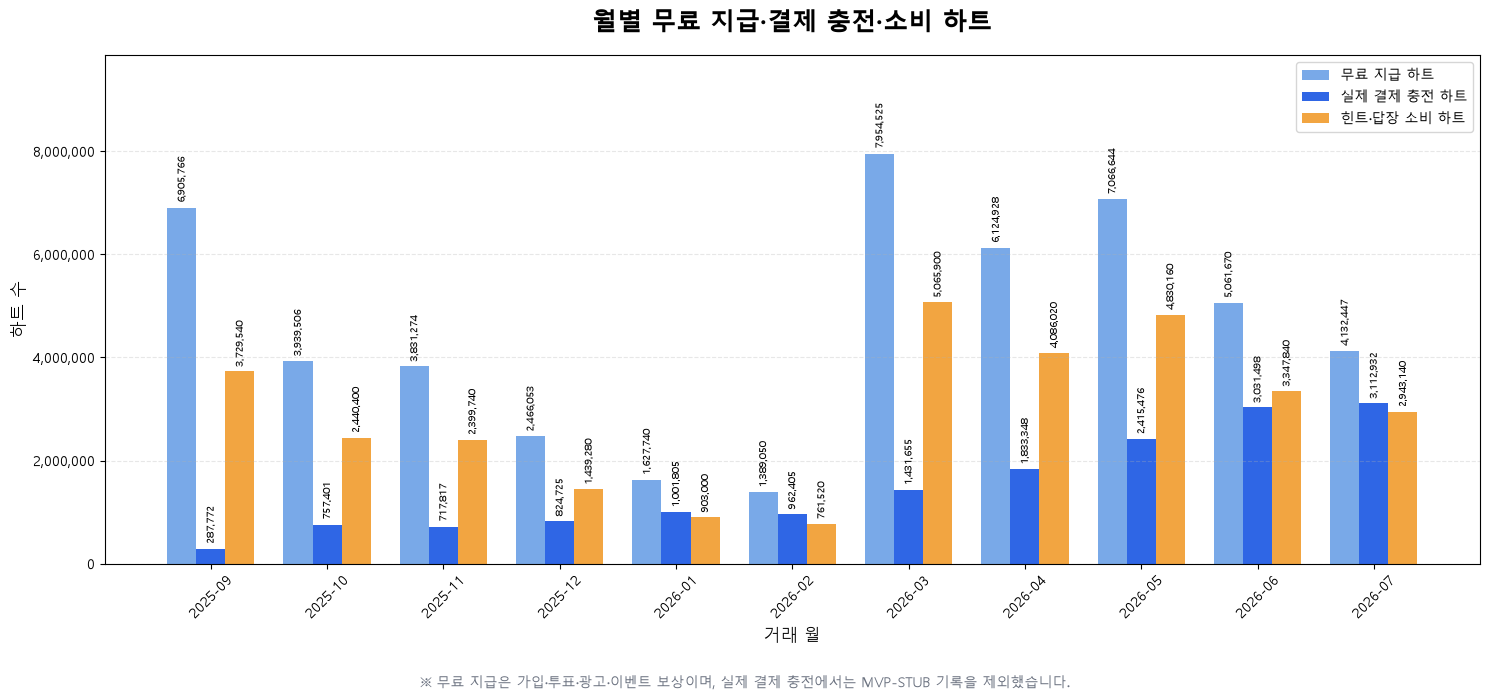

In [60]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = heart_source_df.copy()

plot_df["transaction_month"] = pd.to_datetime(
    plot_df["transaction_month"]
)

plot_df = plot_df.sort_values("transaction_month")

month_labels = plot_df[
    "transaction_month"
].dt.strftime("%Y-%m")

x = list(range(len(plot_df)))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(15, 7))

free_bars = ax.bar(
    [index - bar_width for index in x],
    plot_df["free_received_heart"],
    width=bar_width,
    color="#79A9E8",
    label="무료 지급 하트"
)

paid_bars = ax.bar(
    x,
    plot_df["paid_topup_heart"],
    width=bar_width,
    color="#2F66E5",
    label="실제 결제 충전 하트"
)

spent_bars = ax.bar(
    [index + bar_width for index in x],
    plot_df["user_spent_heart"],
    width=bar_width,
    color="#F2A541",
    label="힌트·답장 소비 하트"
)

ax.set_title(
    "월별 무료 지급·결제 충전·소비 하트",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("거래 월", fontsize=12)
ax.set_ylabel("하트 수", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(
    month_labels,
    rotation=45
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{int(value):,}"
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

max_value = max(
    plot_df["free_received_heart"].max(),
    plot_df["paid_topup_heart"].max(),
    plot_df["user_spent_heart"].max()
)

label_offset = max_value * 0.012

for bars in [free_bars, paid_bars, spent_bars]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + label_offset,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

ax.set_ylim(0, max_value * 1.24)

plt.figtext(
    0.5,
    0.01,
    "※ 무료 지급은 가입·투표·광고·이벤트 보상이며, 실제 결제 충전에서는 MVP-STUB 기록을 제외했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [61]:
# 일별 접속자·투표 참여 쿼리
access_vote_sql = """
-- 일별 접속 사용자 중 실제 투표 참여 현황
WITH current_users AS (
  SELECT
    id AS user_id,
    is_synthetic
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

withdrawn_users AS (
  SELECT DISTINCT
    user_id
  FROM `ping-v2-503916.raw.user_withdrawal`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

valid_users AS (
  SELECT
    u.user_id
  FROM current_users AS u
  LEFT JOIN withdrawn_users AS w
    ON u.user_id = w.user_id
  WHERE u.is_synthetic = TRUE
    AND w.user_id IS NULL
),

current_sessions AS (
  SELECT
    id AS session_id,
    user_id,
    started_at
  FROM `ping-v2-503916.raw.user_session`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
    AND started_at IS NOT NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

current_vote_items AS (
  SELECT
    id AS vote_item_id,
    user_id,
    voted_at
  FROM `ping-v2-503916.raw.vote_item`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
    AND voted_at IS NOT NULL
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id
    ORDER BY updated_at DESC
  ) = 1
),

-- 사용자별 일간 접속 기록
daily_access_users AS (
  SELECT DISTINCT
    DATE(
      s.started_at,
      'Asia/Seoul'
    ) AS activity_date,
    s.user_id
  FROM current_sessions AS s
  INNER JOIN valid_users AS u
    ON s.user_id = u.user_id
),

-- 사용자별 일간 실제 투표 수
daily_user_votes AS (
  SELECT
    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date,
    v.user_id,
    COUNT(*) AS vote_count
  FROM current_vote_items AS v
  INNER JOIN valid_users AS u
    ON v.user_id = u.user_id
  GROUP BY
    activity_date,
    v.user_id
),

-- 같은 날 접속한 사용자에게 투표 기록 연결
daily_user_activity AS (
  SELECT
    a.activity_date,
    a.user_id,
    COALESCE(v.vote_count, 0) AS vote_count
  FROM daily_access_users AS a
  LEFT JOIN daily_user_votes AS v
    ON a.activity_date = v.activity_date
    AND a.user_id = v.user_id
),

daily_summary AS (
  SELECT
    activity_date,

    COUNT(DISTINCT user_id)
      AS daily_active_user_count,

    COUNT(
      DISTINCT IF(
        vote_count > 0,
        user_id,
        NULL
      )
    ) AS daily_voter_count,

    SUM(vote_count) AS daily_vote_count

  FROM daily_user_activity
  GROUP BY activity_date
),

overall_summary AS (
  SELECT
    SUM(daily_active_user_count)
      AS total_active_user_days,

    SUM(daily_voter_count)
      AS total_voter_days,

    SUM(daily_vote_count)
      AS total_vote_count,

    ROUND(
      SAFE_DIVIDE(
        SUM(daily_voter_count),
        SUM(daily_active_user_count)
      ) * 100,
      2
    ) AS overall_vote_participation_percent,

    ROUND(
      SAFE_DIVIDE(
        SUM(daily_vote_count),
        SUM(daily_active_user_count)
      ),
      2
    ) AS overall_votes_per_active_user,

    ROUND(
      SAFE_DIVIDE(
        SUM(daily_vote_count),
        SUM(daily_voter_count)
      ),
      2
    ) AS overall_votes_per_voter

  FROM daily_summary
)

SELECT
  d.activity_date,
  d.daily_active_user_count,
  d.daily_voter_count,
  d.daily_vote_count,

  ROUND(
    SAFE_DIVIDE(
      d.daily_voter_count,
      d.daily_active_user_count
    ) * 100,
    2
  ) AS vote_participation_percent,

  ROUND(
    SAFE_DIVIDE(
      d.daily_vote_count,
      d.daily_active_user_count
    ),
    2
  ) AS votes_per_active_user,

  ROUND(
    SAFE_DIVIDE(
      d.daily_vote_count,
      d.daily_voter_count
    ),
    2
  ) AS votes_per_voter,

  o.total_active_user_days,
  o.total_voter_days,
  o.total_vote_count,
  o.overall_vote_participation_percent,
  o.overall_votes_per_active_user,
  o.overall_votes_per_voter

FROM daily_summary AS d
CROSS JOIN overall_summary AS o
ORDER BY d.activity_date
"""

In [62]:
cost(access_vote_sql)

예상 스캔량: 533.503 MiB
예상 스캔량: 0.520999 GiB
월 1 TiB 무료 용량의 약 0.05087883%


0.5209992416203022

In [63]:
access_vote_df = bq.query(
    access_vote_sql
).to_dataframe()

display(access_vote_df)

,activity_date,daily_active_user_count,daily_voter_count,daily_vote_count,vote_participation_percent,votes_per_active_user,votes_per_voter,total_active_user_days,total_voter_days,total_vote_count,overall_vote_participation_percent,overall_votes_per_active_user,overall_votes_per_voter
0,2025-09-01,87,10,318,11.49,3.66,31.80,238030,211832,11911532,88.99,50.04,56.23
1,2025-09-02,207,65,1592,31.40,7.69,24.49,238030,211832,11911532,88.99,50.04,56.23
2,2025-09-03,279,133,3507,47.67,12.57,26.37,238030,211832,11911532,88.99,50.04,56.23
3,2025-09-04,375,241,6076,64.27,16.20,25.21,238030,211832,11911532,88.99,50.04,56.23
4,2025-09-05,438,301,9002,68.72,20.55,29.91,238030,211832,11911532,88.99,50.04,56.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,2026-07-19,734,666,69331,90.74,94.46,104.10,238030,211832,11911532,88.99,50.04,56.23
322,2026-07-20,767,685,79779,89.31,104.01,116.47,238030,211832,11911532,88.99,50.04,56.23
323,2026-07-21,744,673,77332,90.46,103.94,114.91,238030,211832,11911532,88.99,50.04,56.23
324,2026-07-22,719,642,57521,89.29,80.00,89.60,238030,211832,11911532,88.99,50.04,56.23


In [64]:
if access_vote_df.empty:
    print("조회된 접속·투표 기록이 없습니다.")

else:
    summary = access_vote_df.iloc[0]

    active_user_days = int(
        summary["total_active_user_days"]
    )

    voter_days = int(
        summary["total_voter_days"]
    )

    total_votes = int(
        summary["total_vote_count"]
    )

    participation_rate = float(
        summary["overall_vote_participation_percent"]
    )

    votes_per_active_user = float(
        summary["overall_votes_per_active_user"]
    )

    votes_per_voter = float(
        summary["overall_votes_per_voter"]
    )

    average_dau = access_vote_df[
        "daily_active_user_count"
    ].mean()

    average_daily_voters = access_vote_df[
        "daily_voter_count"
    ].mean()

    peak_row = access_vote_df.loc[
        access_vote_df[
            "vote_participation_percent"
        ].idxmax()
    ]

    print("[접속 사용자의 투표 참여 분석]")

    print(
        f"일평균 접속 사용자: "
        f"{average_dau:,.1f}명"
    )

    print(
        f"일평균 투표 사용자: "
        f"{average_daily_voters:,.1f}명"
    )

    print(
        f"접속자 중 투표 참여율: "
        f"{participation_rate:.2f}%"
    )

    print(
        f"접속 사용자 1명당 실제 투표 수: "
        f"{votes_per_active_user:.2f}회"
    )

    print(
        f"투표 참여자 1명당 실제 투표 수: "
        f"{votes_per_voter:.2f}회"
    )

    print(f"전체 실제 투표 수: {total_votes:,}회")

    print(
        f"투표 참여율이 가장 높았던 날: "
        f"{peak_row['activity_date']} | "
        f"{float(peak_row['vote_participation_percent']):.2f}%"
    )

[접속 사용자의 투표 참여 분석]
일평균 접속 사용자: 730.2명
일평균 투표 사용자: 649.8명
접속자 중 투표 참여율: 88.99%
접속 사용자 1명당 실제 투표 수: 50.04회
투표 참여자 1명당 실제 투표 수: 56.23회
전체 실제 투표 수: 11,911,532회
투표 참여율이 가장 높았던 날: 2026-01-27 | 97.26%


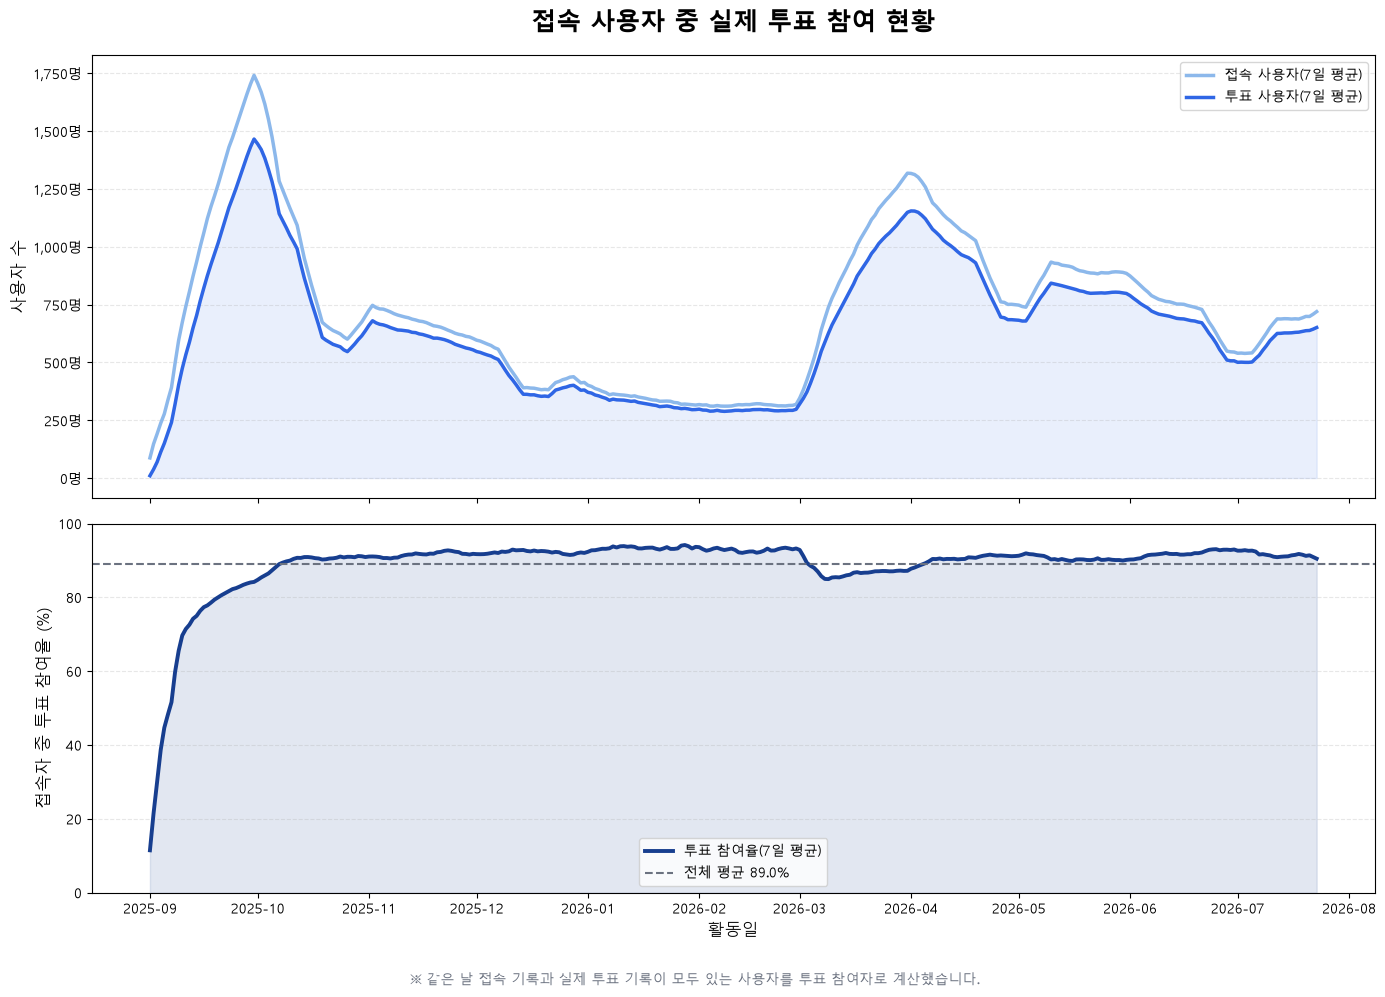

In [65]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

plot_df = access_vote_df.copy()

plot_df["activity_date"] = pd.to_datetime(
    plot_df["activity_date"]
)

plot_df = plot_df.sort_values("activity_date")

# 추세를 보기 위한 7일 이동평균
plot_df["active_user_7day_avg"] = (
    plot_df["daily_active_user_count"]
    .rolling(window=7, min_periods=1)
    .mean()
)

plot_df["voter_7day_avg"] = (
    plot_df["daily_voter_count"]
    .rolling(window=7, min_periods=1)
    .mean()
)

plot_df["participation_7day_avg"] = (
    plot_df["vote_participation_percent"]
    .rolling(window=7, min_periods=1)
    .mean()
)

overall_rate = float(
    plot_df[
        "overall_vote_participation_percent"
    ].iloc[0]
)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1.2, 1]
    }
)

# 위: 접속자와 투표자 수
ax1.plot(
    plot_df["activity_date"],
    plot_df["active_user_7day_avg"],
    color="#8CB8EB",
    linewidth=2.5,
    label="접속 사용자(7일 평균)"
)

ax1.plot(
    plot_df["activity_date"],
    plot_df["voter_7day_avg"],
    color="#2F66E5",
    linewidth=2.5,
    label="투표 사용자(7일 평균)"
)

ax1.fill_between(
    plot_df["activity_date"],
    plot_df["voter_7day_avg"],
    color="#2F66E5",
    alpha=0.1
)

ax1.set_title(
    "접속 사용자 중 실제 투표 참여 현황",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax1.set_ylabel("사용자 수", fontsize=12)

ax1.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{int(value):,}명"
    )
)

ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.legend()

# 아래: 접속자 중 투표 참여율
ax2.plot(
    plot_df["activity_date"],
    plot_df["participation_7day_avg"],
    color="#173E8F",
    linewidth=2.8,
    label="투표 참여율(7일 평균)"
)

ax2.axhline(
    overall_rate,
    color="#6B7280",
    linestyle="--",
    linewidth=1.5,
    label=f"전체 평균 {overall_rate:.1f}%"
)

ax2.fill_between(
    plot_df["activity_date"],
    plot_df["participation_7day_avg"],
    color="#173E8F",
    alpha=0.12
)

ax2.set_xlabel("활동일", fontsize=12)
ax2.set_ylabel("접속자 중 투표 참여율 (%)", fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.legend()

plt.figtext(
    0.5,
    0.01,
    "※ 같은 날 접속 기록과 실제 투표 기록이 모두 있는 사용자를 투표 참여자로 계산했습니다.",
    ha="center",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()